## 📋 Daftar Isi
1. [Setup & Import Libraries](#1-setup)
2. [Data Loading & Eksplorasi](#2-data-loading)
3. [Data Preprocessing](#3-preprocessing)
   - 3.1 Deteksi Outlier (IQR)
   - 3.2 Standarisasi Fitur (StandardScaler)
4. [Penentuan Jumlah Cluster Optimal](#4-optimal-k)
   - 4.1 Elbow Method
   - 4.2 Silhouette Analysis
5. [K-Means Clustering](#5-kmeans)
6. [Ward's Hierarchical Clustering](#6-hierarchical)
   - 6.1 Dendrogram
   - 6.2 Penerapan & Validasi
7. [Visualisasi PCA 2D](#7-pca)
8. [Profil Cluster & Pelabelan Risiko](#8-profiling)
9. [Rekomendasi Strategis](#9-rekomendasi)
10. [Tren Temporal](#10-tren)
11. [Peta Spasial](#11-peta)
12. [Limitasi](#12-limitasi)

## 1. Setup & Import Libraries <a id='1-setup'></a>

In [133]:
# ── Core ─────────────────────────────────────────────────────────────────────
import glob
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score

# ── Hierarchical Clustering ───────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

# ── Global Aesthetics ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
PALETTE     = sns.color_palette('husl', 6)
RANDOM_STATE = 42

print("✅ Semua library berhasil dimuat.")
print(f"   Pandas     : {pd.__version__}")
print(f"   NumPy      : {np.__version__}")
print(f"   Scikit-learn sudah siap.")

✅ Semua library berhasil dimuat.
   Pandas     : 2.3.3
   NumPy      : 2.4.1
   Scikit-learn sudah siap.


## 2. Data Loading & Eksplorasi <a id='2-data-loading'></a>
Data diambil dari **5 file Excel** (2020–2024) yang masing-masing berisi 38 Kabupaten/Kota Jawa Timur.
Baris dengan kata kunci **"Jawa Timur"** (ringkasan provinsi) **diabaikan** sesuai instruksi.
Nilai agregasi multi-tahun menggunakan **median** untuk ketahanan terhadap anomali data.

In [134]:
# ── Konfigurasi ───────────────────────────────────────────────────────────────
DATA_DIR  = "tingkat kriminalitas"
FILES     = sorted(glob.glob(os.path.join(DATA_DIR, "*.xlsx")))

COL_NAMES    = ['Kabupaten_Kota', 'Jumlah_Kejahatan', 'Risiko_100k',
                'Persen_Penyelesaian', 'Selang_Waktu']
FEATURE_COLS = COL_NAMES[1:]

FEATURE_LABELS = {
    'Jumlah_Kejahatan'   : 'Jml Kejahatan\nDilaporkan',
    'Risiko_100k'        : 'Risiko per\n100k Penduduk',
    'Persen_Penyelesaian': '% Penyelesaian\nKasus',
    'Selang_Waktu'       : 'Selang Waktu\nKejadian (jam)',
}

print(f"📂 Ditemukan {len(FILES)} file:")
for f in FILES:
    print(f"   • {os.path.basename(f)}")

📂 Ditemukan 5 file:
   • tingkat kriminalitas 2020.xlsx
   • tingkat kriminalitas 2021.xlsx
   • tingkat kriminalitas 2022.xlsx
   • tingkat kriminalitas 2023.xlsx
   • tingkat kriminalitas 2024.xlsx


In [135]:
def load_year_data(filepath: str) -> pd.DataFrame:
    """
    Memuat satu file Excel, menghapus baris 'Jawa Timur', baris metadata/catatan,
    dan mengkonversi semua kolom numerik.
    """
    year = int(os.path.basename(filepath).split()[-1].replace('.xlsx', ''))
    df   = pd.read_excel(filepath, header=0)
    df.columns = COL_NAMES

    # ① Filter baris 'Jawa Timur' (case-insensitive)
    mask_jatim = df['Kabupaten_Kota'].astype(str).str.lower().str.contains('jawa timur', na=True)
    df = df[~mask_jatim].copy()

    # ② Konversi ke numerik; nilai tidak valid → NaN
    for col in FEATURE_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # ③ Hapus baris metadata (catatan, sumber, HTML-tag, dll.)
    df = df[df['Kabupaten_Kota'].notna()].copy()
    df = df[~df['Kabupaten_Kota'].astype(str).str.match(
        r'^[<\d]|catatan|sumber|source|note', flags=0, na=True
    )].copy()

    # ④ Hanya simpan baris dengan ≥ 3 kolom numerik valid
    valid_mask = df[FEATURE_COLS].notna().sum(axis=1) >= 3
    df = df[valid_mask].copy()

    df['Tahun'] = year
    return df


# ── Load & gabungkan ──────────────────────────────────────────────────────────
dfs    = [load_year_data(f) for f in FILES]
df_raw = pd.concat(dfs, ignore_index=True)
df_raw[FEATURE_COLS] = df_raw[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')

print(f"✅ Total rekaman: {len(df_raw)}")
print(f"   Tahun     : {sorted(df_raw['Tahun'].unique())}")
print(f"   Kabupaten : {df_raw['Kabupaten_Kota'].nunique()} daerah unik")
df_raw.head(10)

✅ Total rekaman: 190
   Tahun     : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
   Kabupaten : 38 daerah unik


,Kabupaten_Kota,Jumlah_Kejahatan,Risiko_100k,Persen_Penyelesaian,Selang_Waktu,Tahun
0,Pacitan,72.0,13.0,90.28,100.0,2020
1,Ponorogo,402.0,47.0,87.81,1307.0,2020
2,Trenggalek,595.0,88.0,90.59,883.0,2020
3,Tulungagung,538.0,54.0,100.74,977.0,2020
4,Blitar,304.0,27.0,27.30,289.0,2020
5,Kediri,862.0,57.0,38.75,610.0,2020
6,Malang,1850.0,75.0,69.35,284.0,2020
7,Lumajang,356.0,35.0,12.64,36.0,2020
8,Jember,1061.0,45.0,62.49,495.0,2020
9,Banyuwangi,893.0,57.0,47.70,589.0,2020


In [136]:
# ── Agregasi multi-tahun: median per Kabupaten/Kota ──────────────────────────
# Median lebih robust terhadap anomali data tahun tertentu (mis. 2024)
df_profile = (df_raw
              .groupby('Kabupaten_Kota', sort=True)[FEATURE_COLS]
              .median()
              .reset_index())

print(f"✅ Dataset profil final: {df_profile.shape[0]} Kabupaten/Kota × {len(FEATURE_COLS)} fitur")
print("\n📊 Statistik Deskriptif:")
df_profile[FEATURE_COLS].describe().round(2)

✅ Dataset profil final: 38 Kabupaten/Kota × 4 fitur

📊 Statistik Deskriptif:


,Jumlah_Kejahatan,Risiko_100k,Persen_Penyelesaian,Selang_Waktu
count,38.00,38.00,38.00,38.00
mean,1122.82,54.32,86.18,657.27
std,441.28,47.67,13.02,239.75
min,300.00,6.00,46.42,231.60
25%,764.25,28.50,81.60,447.00
50%,1057.50,42.50,86.24,682.00
75%,1501.75,56.25,95.29,835.75
max,2009.00,222.00,109.16,1215.00


### 2.1 Histogram Distribusi Variabel
Visualisasi distribusi setiap variabel numerik dengan anotasi **mean**, **median**, serta ringkasan statistik dasar (min, Q1, median, Q3, max).

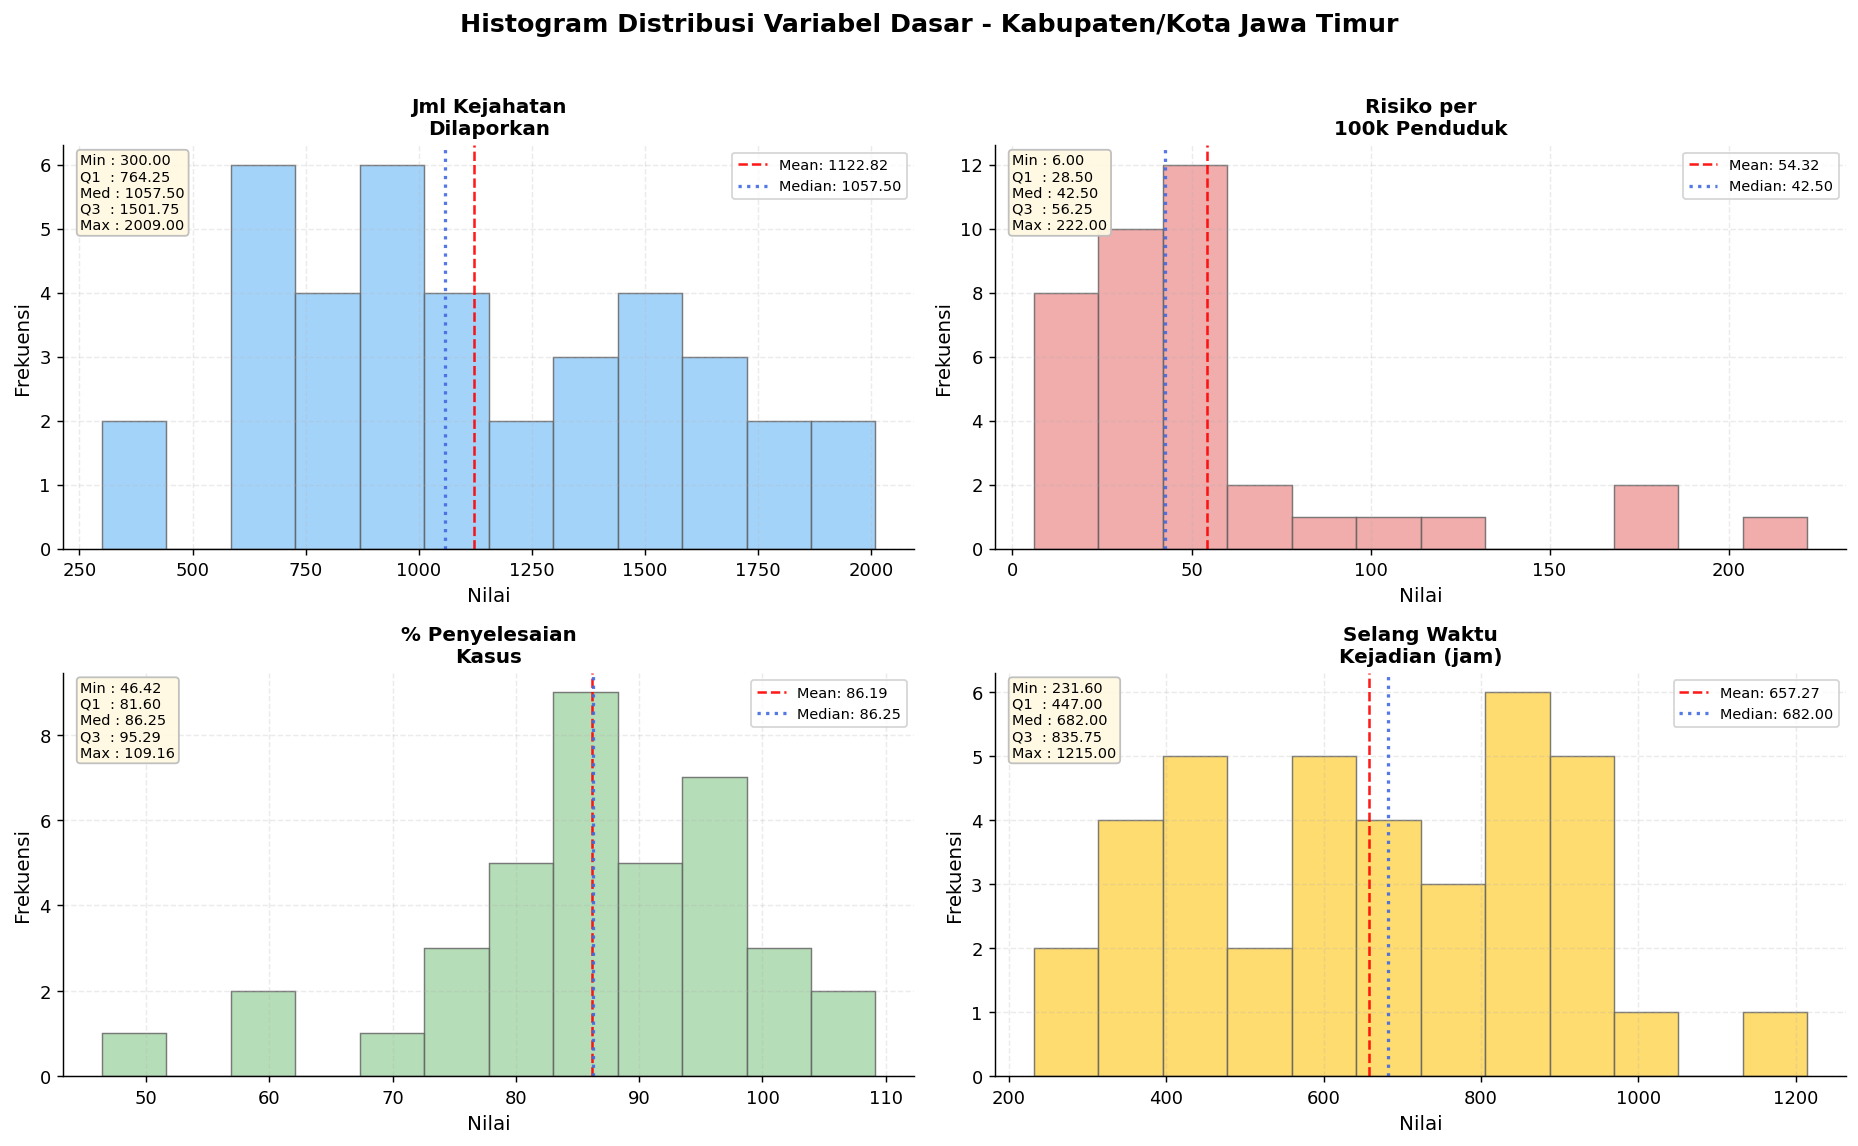

In [137]:
# ── Histogram Distribusi Variabel (gaya dashboard statistik) ──────────────────
hist_cols = FEATURE_COLS.copy()

n_vars = len(hist_cols)
ncols = 2 if n_vars <= 4 else 3
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.3 * nrows))
axes = np.array(axes).reshape(-1)

hist_colors = ['#90CAF9', '#EF9A9A', '#A5D6A7', '#FFD54F', '#CE93D8', '#80CBC4']

for i, col in enumerate(hist_cols):
    ax = axes[i]
    x = df_profile[col].dropna()

    mean_val = x.mean()
    med_val = x.median()
    q1, q3 = x.quantile([0.25, 0.75])
    min_val, max_val = x.min(), x.max()

    ax.hist(
        x,
        bins=12,
        color=hist_colors[i % len(hist_colors)],
        edgecolor='#616161',
        linewidth=0.8,
        alpha=0.82,
    )

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.4, alpha=0.9,
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(med_val, color='royalblue', linestyle=':', linewidth=1.8, alpha=0.9,
               label=f'Median: {med_val:.2f}')

    stats_text = (
        f"Min : {min_val:.2f}\n"
        f"Q1  : {q1:.2f}\n"
        f"Med : {med_val:.2f}\n"
        f"Q3  : {q3:.2f}\n"
        f"Max : {max_val:.2f}"
    )
    ax.text(
        0.02, 0.98, stats_text,
        transform=ax.transAxes,
        fontsize=8,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#FFF8E1', edgecolor='#BDBDBD', alpha=0.95),
    )

    ax.set_title(FEATURE_LABELS.get(col, col), fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.grid(alpha=0.25, linestyle='--')
    ax.legend(loc='upper right', fontsize=8, frameon=True)

for j in range(n_vars, len(axes)):
    axes[j].axis('off')

plt.suptitle('Histogram Distribusi Variabel Dasar - Kabupaten/Kota Jawa Timur',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogram_distribusi_variabel.png', bbox_inches='tight', dpi=130)
plt.show()

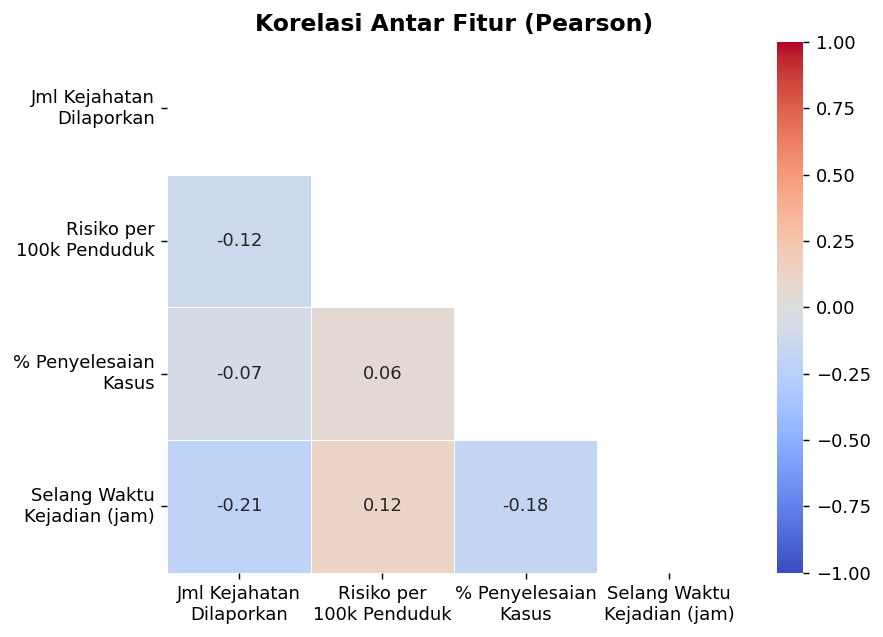

In [138]:
# ── Pearson Correlation Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_profile[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=list(FEATURE_LABELS.values()),
            yticklabels=list(FEATURE_LABELS.values()))
ax.set_title('Korelasi Antar Fitur (Pearson)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', dpi=130)
plt.show()

### Interpretasi Ahli: Signifikansi Korelasi Rendah Antar Fitur

Secara sekilas, visualisasi *Correlation Heatmap* di atas menunjukkan profil **korelasi yang sangat rendah hingga moderat** antar keempat variabel masukan. Dalam konteks pemodelan analitik ini, nilai korelasi yang rendah justru **memvalidasi keberhasilan proses pemilihan (*feature engineering*)** yang telah kita lakukan:

1. **Nihil Redundansi (Tidak Ada Multikolinieritas Parah):** Setiap variabel membawa informasi dan "sinyal" yang unik tentang dinamika wilayah. Misalnya, *Jumlah Kejahatan* (volume absolut) ternyata tidak berimbas mutlak pada *Risiko 100k* (kerawanan per kapita), dan *Persen Penyelesaian* tidak mutlak berhubungan dengan tingginya *Selang Waktu*.
2. **Justifikasi StandardScaler:** Karena tidak ada dimensi yang sifatnya berlebihan/redundan, menyingkirkan/menggabungkan fitur via transformasi *Principal Component Analysis (PCA)* untuk keperluan *clustering* justru dapat merusak struktur informasi asli. Hal ini menjadi **pembenaran/justifikasi teknis kuat bahwa penggunaan StandardScaler murni (tanpa PCA reduksi)** di dalam *pre-processing pipeline clustering* (sebelum algoritma K-Means masuk) adalah keputusan paling valid dan tepat guna mempertahankan dimensi faktual kriminologi.

## 3. Data Preprocessing <a id='3-preprocessing'></a>
### 3.1 Deteksi & Penanganan Outlier — Metode IQR
Nilai ekstrem diidentifikasi dengan batas **IQR × 1.5** dan dikap (*Winsorization*)
agar jumlah Kabupaten/Kota tetap 38 data point.

| Arah Ekstrem | Interpretasi Risiko |
|---|---|
| `Jumlah_Kejahatan` tinggi | Beban kasus besar |
| `Risiko_100k` tinggi | Kerawanan wilayah tinggi |
| `Persen_Penyelesaian` sangat rendah | Kapasitas aparat menurun |
| `Selang_Waktu` sangat pendek | Frekuensi kejadian sangat tinggi |

In [139]:
def detect_and_cap_iqr(df: pd.DataFrame, cols: list) -> tuple[pd.DataFrame, dict]:
    """
    Deteksi outlier IQR dan terapkan Winsorization (capping).
    Returns: (df_clean, report_dict)
    """
    df_out = df.copy()
    report = {}

    for col in cols:
        q1   = df[col].quantile(0.25)
        q3   = df[col].quantile(0.75)
        iqr  = q3 - q1
        lo   = q1 - 1.5 * iqr
        hi   = q3 + 1.5 * iqr

        outlier_idx  = df[(df[col] < lo) | (df[col] > hi)].index
        outlier_kota = df.loc[outlier_idx, 'Kabupaten_Kota'].tolist()

        df_out[col] = df_out[col].clip(lower=lo, upper=hi)
        report[col] = dict(Q1=q1, Q3=q3, IQR=iqr,
                           lower=lo, upper=hi,
                           outliers=outlier_kota,
                           n_outliers=len(outlier_kota))
    return df_out, report


df_clean, iqr_report = detect_and_cap_iqr(df_profile, FEATURE_COLS)

# ── Cetak laporan ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  LAPORAN DETEKSI OUTLIER — METODE IQR (Threshold = 1.5×IQR)")
print("=" * 65)
for col, info in iqr_report.items():
    status = f"⚠️  {info['n_outliers']} daerah" if info['n_outliers'] else "✅ Tidak ada"
    print(f"\n  {col}")
    print(f"    Batas bawah : {info['lower']:>10.2f}  |  Batas atas : {info['upper']:>10.2f}")
    print(f"    Outlier     : {status}")
    if info['outliers']:
        print(f"    Daerah      : {', '.join(info['outliers'])}")

  LAPORAN DETEKSI OUTLIER — METODE IQR (Threshold = 1.5×IQR)

  Jumlah_Kejahatan
    Batas bawah :    -342.00  |  Batas atas :    2608.00
    Outlier     : ✅ Tidak ada

  Risiko_100k
    Batas bawah :     -13.12  |  Batas atas :      97.88
    Outlier     : ⚠️  5 daerah
    Daerah      : Kota Kediri, Kota Mojokerto, Kota Pasuruan, Kota Probolinggo, Magetan

  Persen_Penyelesaian
    Batas bawah :      61.07  |  Batas atas :     115.83
    Outlier     : ⚠️  3 daerah
    Daerah      : Kota Malang, Situbondo, Sumenep

  Selang_Waktu
    Batas bawah :    -136.12  |  Batas atas :    1418.88
    Outlier     : ✅ Tidak ada


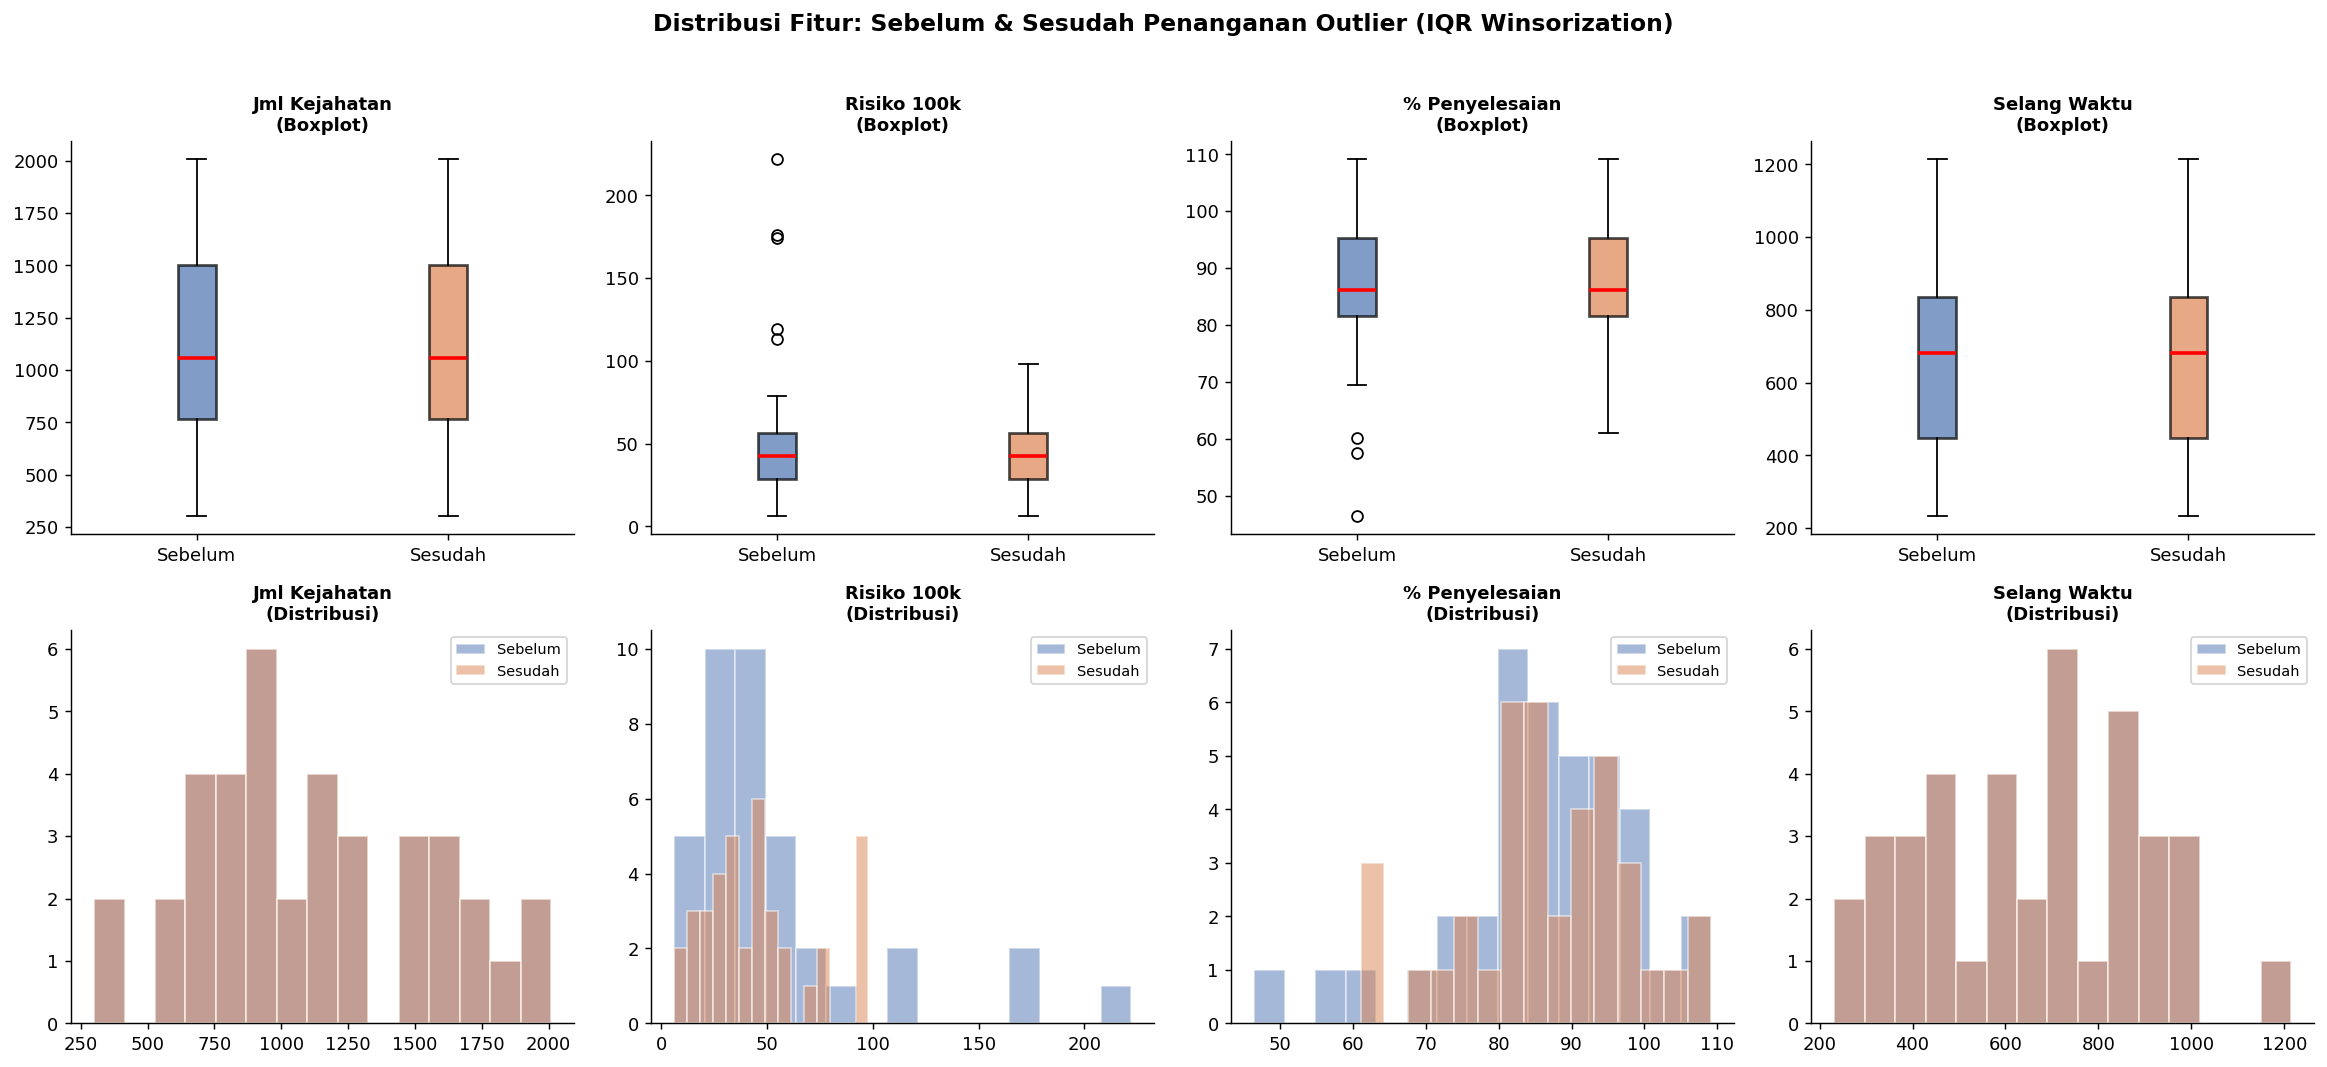

In [140]:
# ── Visualisasi Before vs After Winsorization ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
short_labels = ['Jml Kejahatan', 'Risiko 100k', '% Penyelesaian', 'Selang Waktu']
palette_box  = ['#4C72B0', '#DD8452']

for i, (col, lbl) in enumerate(zip(FEATURE_COLS, short_labels)):
    # Boxplot Before / After
    ax_box = axes[0, i]
    bp = ax_box.boxplot(
        [df_profile[col].dropna().values, df_clean[col].dropna().values],
        labels=['Sebelum', 'Sesudah'], patch_artist=True,
        medianprops=dict(color='red', linewidth=2),
        boxprops=dict(linewidth=1.5),
    )
    for patch, color in zip(bp['boxes'], palette_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_box.set_title(f'{lbl}\n(Boxplot)', fontsize=10, fontweight='bold')

    # Histogram
    ax_hist = axes[1, i]
    ax_hist.hist(df_profile[col].dropna(), bins=15, alpha=0.5,
                 color=palette_box[0], label='Sebelum', edgecolor='white')
    ax_hist.hist(df_clean[col].dropna(), bins=15, alpha=0.5,
                 color=palette_box[1], label='Sesudah', edgecolor='white')
    ax_hist.set_title(f'{lbl}\n(Distribusi)', fontsize=10, fontweight='bold')
    ax_hist.legend(fontsize=8)

fig.suptitle('Distribusi Fitur: Sebelum & Sesudah Penanganan Outlier (IQR Winsorization)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_handling.png', bbox_inches='tight', dpi=130)
plt.show()

### 3.2 Standarisasi Fitur — StandardScaler (Z-Score Normalization)
StandardScaler mengubah setiap fitur menjadi distribusi dengan **mean = 0** dan **std = 1**,
sehingga perbedaan skala antar variabel tidak mendominasi perhitungan jarak cluster.

Verifikasi StandardScaler:
                     Mean (harus ≈ 0)  Std  (harus ≈ 1)
Jumlah_Kejahatan                  0.0               1.0
Risiko_100k                      -0.0               1.0
Persen_Penyelesaian              -0.0               1.0
Selang_Waktu                      0.0               1.0


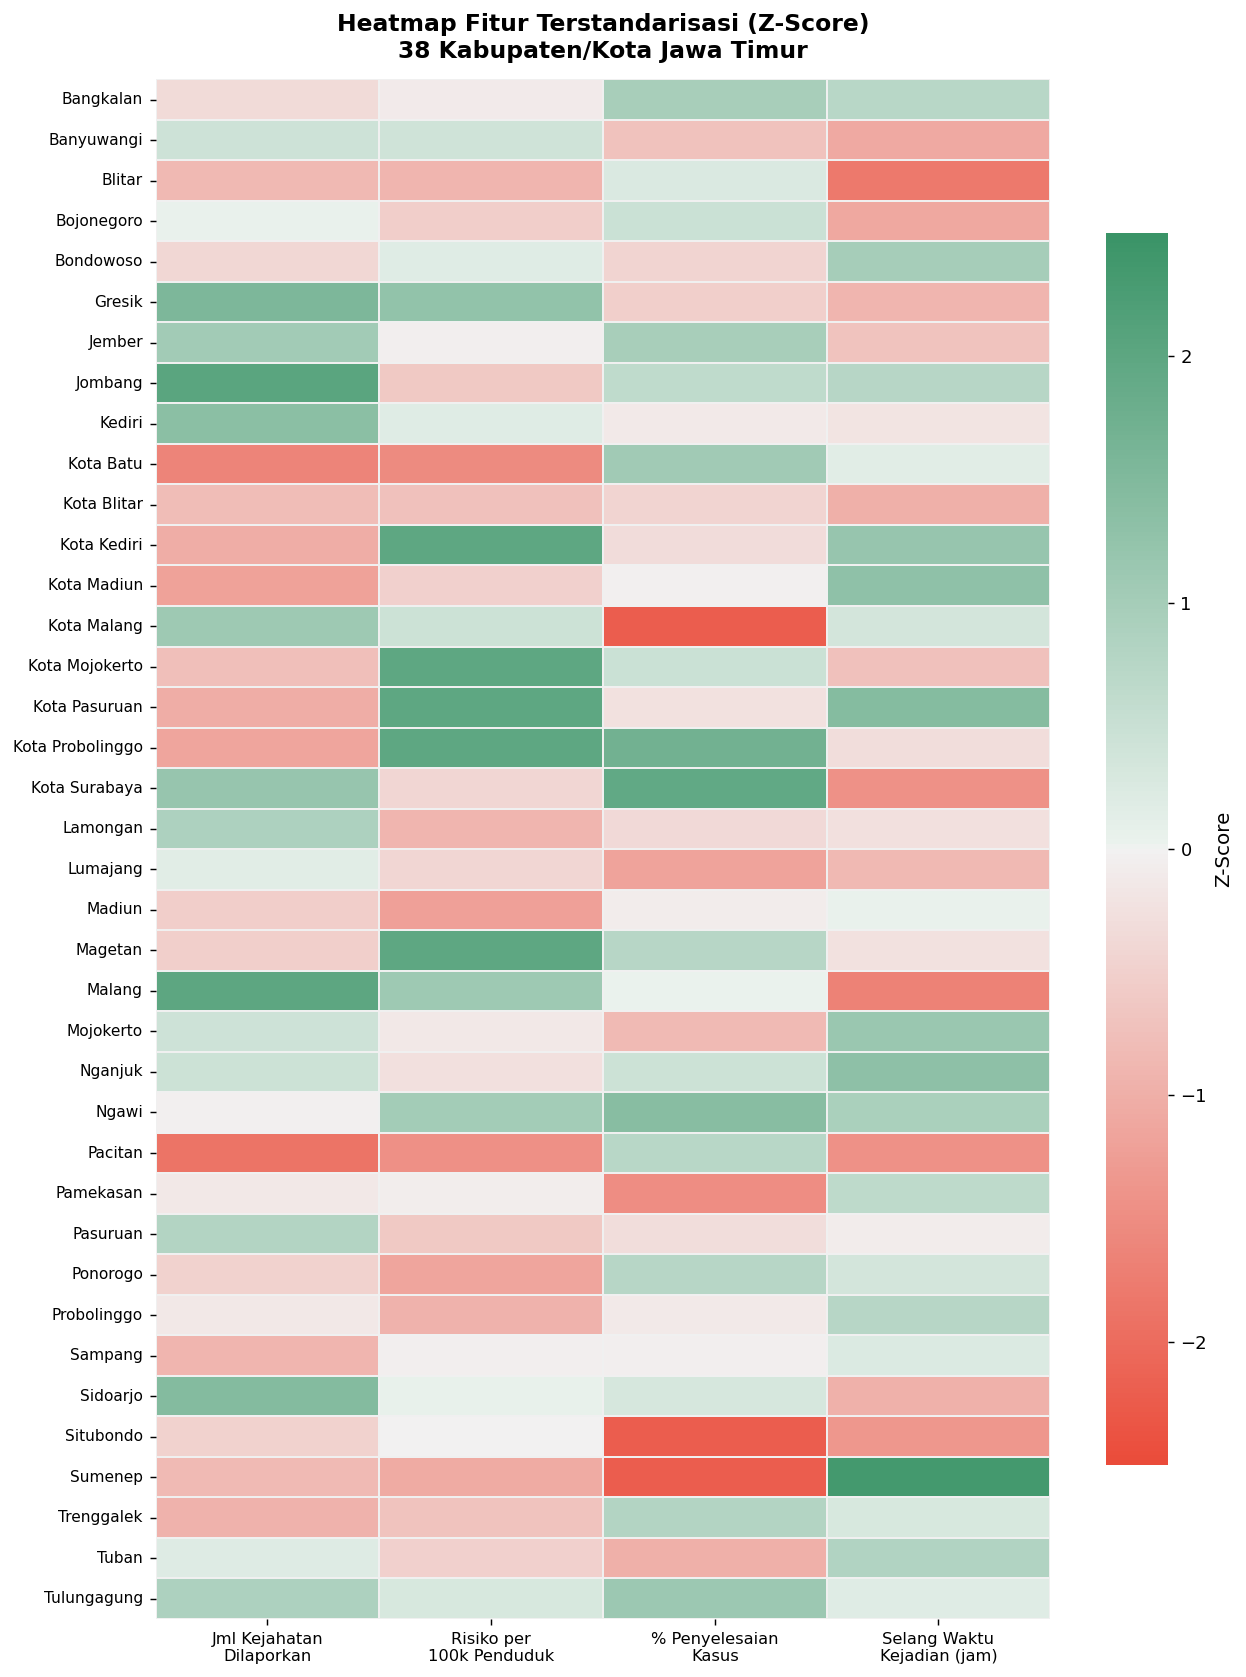

In [141]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURE_COLS])
X_df     = pd.DataFrame(X_scaled, columns=FEATURE_COLS,
                         index=df_clean['Kabupaten_Kota'].values)

print("Verifikasi StandardScaler:")
stat_df = pd.DataFrame({
    'Mean (harus ≈ 0)': X_scaled.mean(axis=0).round(6),
    'Std  (harus ≈ 1)': X_scaled.std(axis=0).round(6),
}, index=FEATURE_COLS)
print(stat_df.to_string())

# ── Heatmap Fitur Terstandarisasi ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 13))
cmap    = sns.diverging_palette(15, 145, s=80, l=55, as_cmap=True)

sns.heatmap(X_df,
            cmap=cmap, center=0, vmin=-2.5, vmax=2.5,
            annot=False, linewidths=0.25, linecolor='#f0f0f0',
            xticklabels=list(FEATURE_LABELS.values()),
            yticklabels=X_df.index, ax=ax,
            cbar_kws={'label': 'Z-Score', 'shrink': 0.8})

ax.set_title('Heatmap Fitur Terstandarisasi (Z-Score)\n38 Kabupaten/Kota Jawa Timur',
             fontweight='bold', pad=12)
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('feature_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

## 4. Penentuan Jumlah Cluster Optimal <a id='4-optimal-k'></a>
Empat metrik digunakan secara paralel untuk konfirmasi silang dan menjaga keseimbangan antara **stabilitas statistik** dan **granularitas kebijakan**.

| Metode | Kriteria Pemilihan K |
|---|---|
| **Elbow Method (WCSS)** | Titik infleksi (knee) pada kurva WCSS |
| **Silhouette Analysis** | Nilai koefisien Silhouette tertinggi |
| **Calinski-Harabasz (CH)** | Nilai CH tertinggi |
| **Davies-Bouldin (DB)** | Nilai DB terendah |

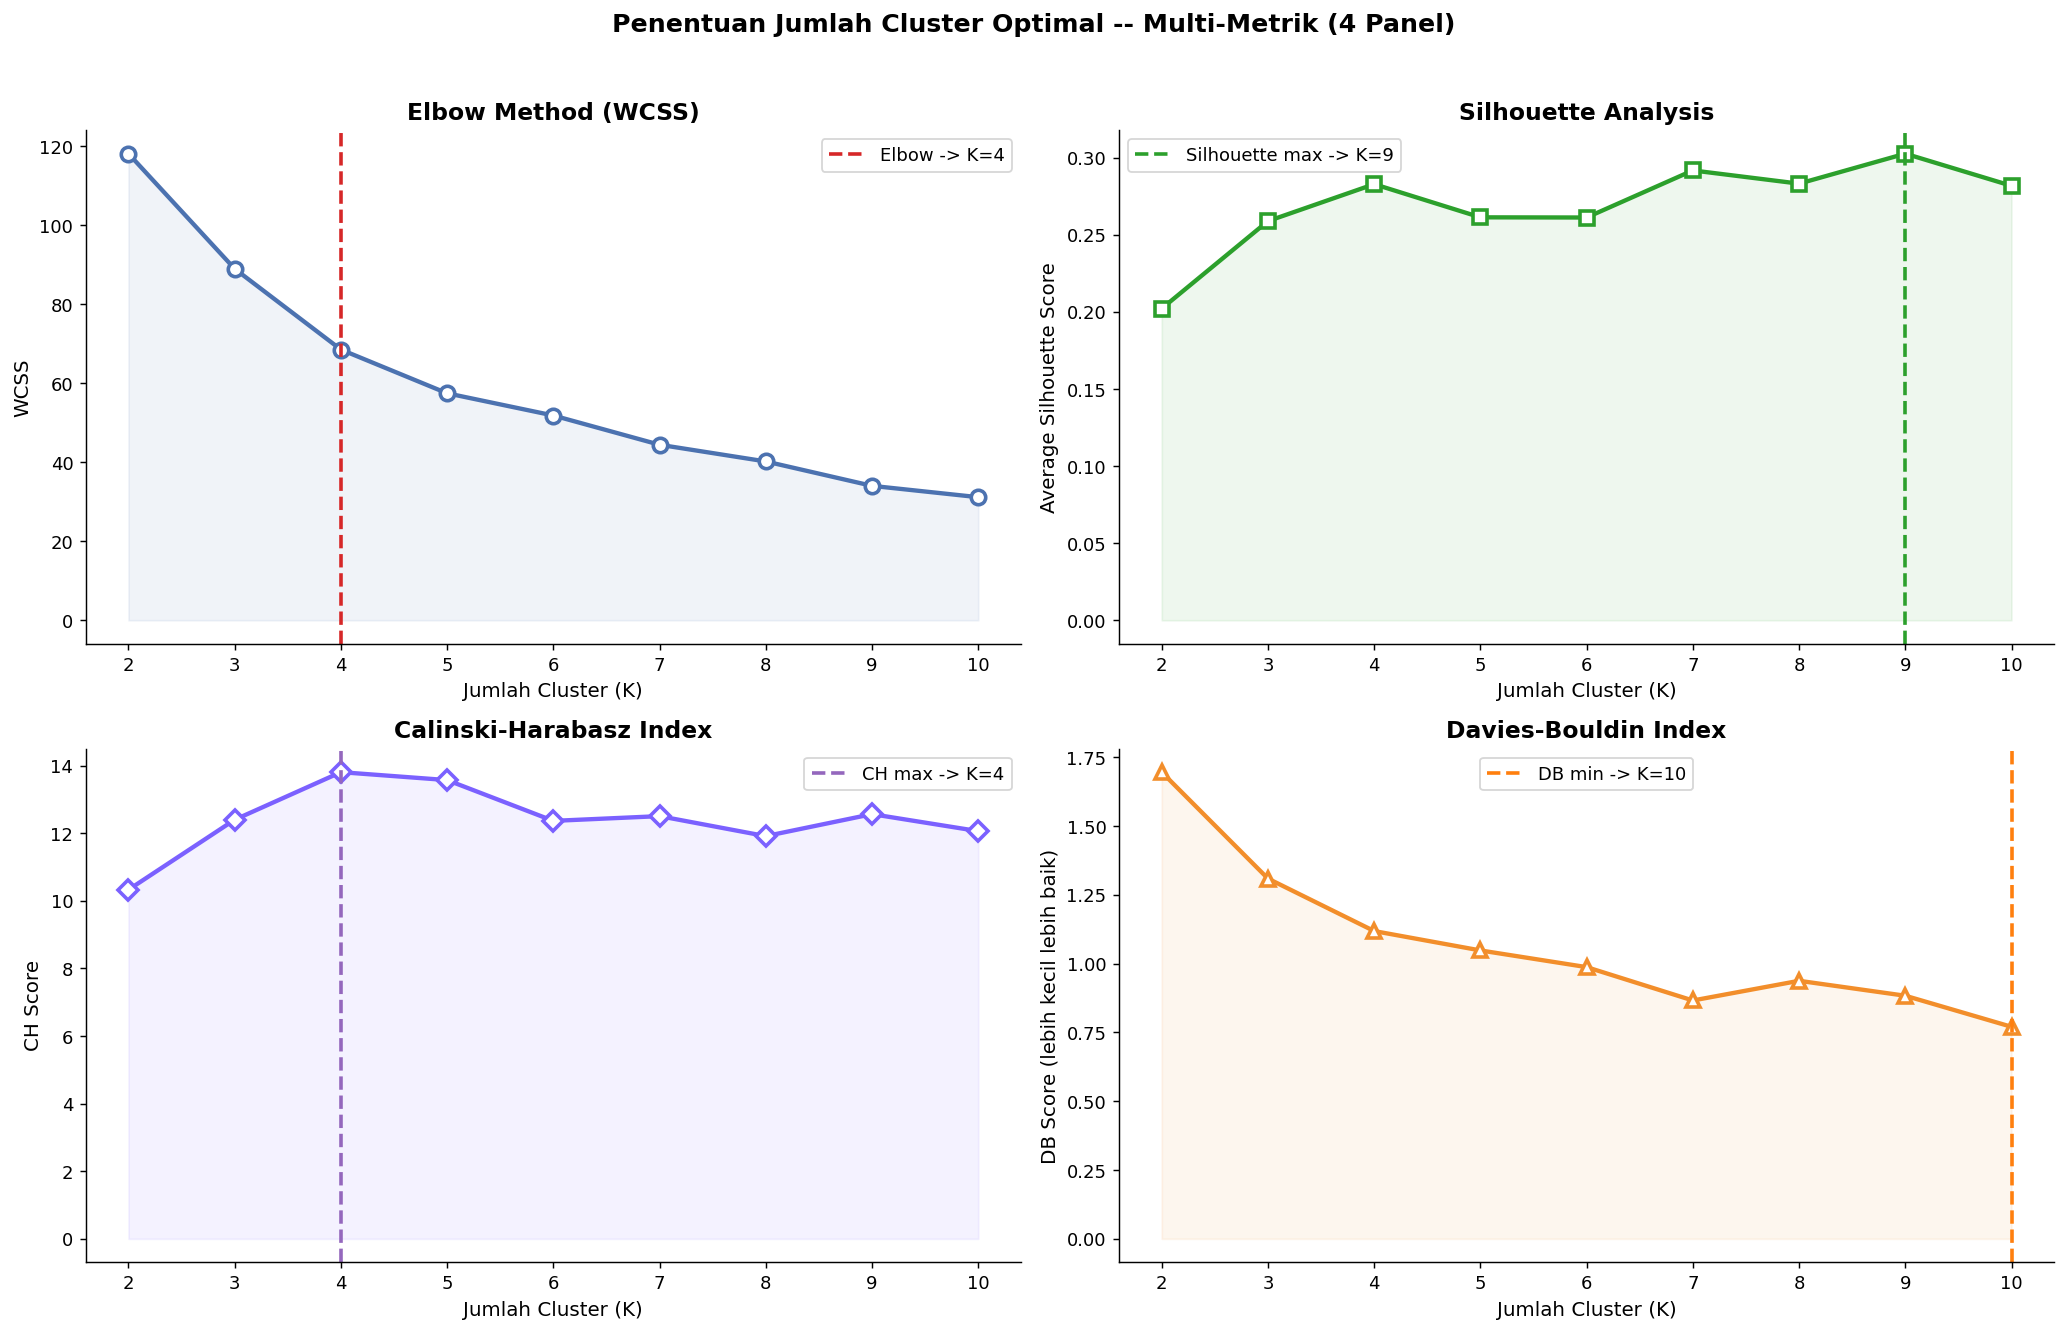

,K,WCSS,Silhouette,Calinski-Harabasz,Davies-Bouldin,Min Anggota Cluster,Cluster <4 Anggota,Lolos Min Anggota
0,2,118.1111,0.2022,10.3293,1.6959,16,0,Ya
1,3,88.9610,0.2589,12.4007,1.3091,6,0,Ya
2,4,68.5187,0.2829,13.8082,1.1184,6,0,Ya
3,5,57.4606,0.2614,13.5736,1.0480,4,0,Ya
4,6,51.8360,0.2613,12.3669,0.9874,2,1,Tidak
5,7,44.4343,0.2918,12.5074,0.8661,2,2,Tidak
6,8,40.2079,0.2832,11.9158,0.9377,2,2,Tidak
7,9,34.0311,0.3027,12.5661,0.8834,2,3,Tidak
8,10,31.1631,0.2818,12.0636,0.7705,1,5,Tidak



📏 K pertama yang memenuhi syarat minimum 4 anggota di semua cluster: K = 2
🔎 K paling granular yang masih memenuhi syarat minimum 4: K = 5


,Metrik,Arah Optimasi,K Optimal,Bobot,Argumen
0,Elbow (WCSS),Knee point,4,0.15,Parsimoni dan diminishing return WCSS
1,Silhouette,Maksimum,9,0.30,Kohesi intra-cluster dan separasi antar-cluster
2,Calinski-Harabasz,Maksimum,4,0.30,Rasio dispersi antar-cluster vs intra-cluster
3,Davies-Bouldin,Minimum,10,0.25,Kemiripan antarklaster (lebih kecil lebih baik)


,K,Jumlah Suara,Skor Bobot
0,4,2,0.45
1,9,1,0.30
2,10,1,0.25
3,2,0,0.00
4,3,0,0.00
5,5,0,0.00
6,6,0,0.00
7,7,0,0.00
8,8,0,0.00



Ringkasan K optimal tiap metrik:
          Elbow (WCSS) -> K = 4
            Silhouette -> K = 9
     Calinski-Harabasz -> K = 4
        Davies-Bouldin -> K = 10

🎯 OPTIMAL_K (hasil aturan keputusan): K = 4
📝 Metrik bertentangan, namun skor bobot tertinggi jatuh pada K=4. Keputusan ini adalah trade-off: granularitas segmentasi lebih kasar, tetapi stabilitas statistik relatif lebih kuat. K=4 juga memenuhi syarat minimum 4 anggota per cluster.
⚠️ Untuk K=9 terdapat cluster kecil (minimum 2 anggota; 3 cluster < 4 anggota). Jika K=9 tetap dipertahankan, cluster kecil harus diperlakukan sebagai kasus khusus yang wajib verifikasi lapangan, bukan basis kebijakan langsung.

🔍 Analisis Lanjutan Davies-Bouldin (K=10):
Meskipun metrik Davies-Bouldin menunjuk K=10 sebagai nilai minimum (terbaik), K=10 tidak dipilih
karena ada cluster yang anggotanya < 4 daerah (melanggar batas guardrail MIN_CLUSTER_SIZE).
Keputusan ini memastikan bahwa klaster yang terbentuk cukup representatif untuk kebijakan ta

In [142]:
MIN_CLUSTER_SIZE = 4
K_RANGE = range(2, 11)

wcss_list = []
silh_list = []
ch_list   = []
db_list   = []
min_members_list = []
small_cluster_count_list = []
cluster_size_map = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25, max_iter=500)
    labels = km.fit_predict(X_scaled)

    cluster_sizes = np.bincount(labels, minlength=k)
    cluster_size_map[k] = cluster_sizes.tolist()

    min_members_list.append(int(cluster_sizes.min()))
    small_cluster_count_list.append(int((cluster_sizes < MIN_CLUSTER_SIZE).sum()))

    wcss_list.append(km.inertia_)
    silh_list.append(silhouette_score(X_scaled, labels))
    ch_list.append(calinski_harabasz_score(X_scaled, labels))
    db_list.append(davies_bouldin_score(X_scaled, labels))

# -- Titik optimum masing-masing metrik ----------------------------------------
diffs1 = np.diff(wcss_list)
diffs2 = np.diff(diffs1)
elbow_k = list(K_RANGE)[np.argmax(diffs2) + 1]

best_silh_k = list(K_RANGE)[np.argmax(silh_list)]
best_ch_k   = list(K_RANGE)[np.argmax(ch_list)]
best_db_k   = list(K_RANGE)[np.argmin(db_list)]

metric_k = {
    'Elbow (WCSS)': elbow_k,
    'Silhouette': best_silh_k,
    'Calinski-Harabasz': best_ch_k,
    'Davies-Bouldin': best_db_k,
}

metric_colors = {
    'Elbow (WCSS)': '#D62728',
    'Silhouette': '#2CA02C',
    'Calinski-Harabasz': '#9467BD',
    'Davies-Bouldin': '#FF7F0E',
}

# -- Plot 4 panel: WCSS, Silhouette, CH, DB -----------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# Panel 1 -- WCSS
axes[0].plot(K_RANGE, wcss_list, 'o-', color='#4C72B0', linewidth=2.4, markersize=8,
             markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(K_RANGE, wcss_list, alpha=0.08, color='#4C72B0')
axes[0].axvline(metric_k['Elbow (WCSS)'], color=metric_colors['Elbow (WCSS)'], linestyle='--', linewidth=2,
                label=f"Elbow -> K={metric_k['Elbow (WCSS)']}")
axes[0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('WCSS')
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()

# Panel 2 -- Silhouette
axes[1].plot(K_RANGE, silh_list, 's-', color='#2CA02C', linewidth=2.4, markersize=8,
             markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(K_RANGE, silh_list, alpha=0.08, color='#2CA02C')
axes[1].axvline(metric_k['Silhouette'], color=metric_colors['Silhouette'], linestyle='--', linewidth=2,
                label=f"Silhouette max -> K={metric_k['Silhouette']}")
axes[1].set_title('Silhouette Analysis', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

# Panel 3 -- Calinski-Harabasz
axes[2].plot(K_RANGE, ch_list, 'D-', color='#7B61FF', linewidth=2.4, markersize=8,
             markerfacecolor='white', markeredgewidth=2)
axes[2].fill_between(K_RANGE, ch_list, alpha=0.08, color='#7B61FF')
axes[2].axvline(metric_k['Calinski-Harabasz'], color=metric_colors['Calinski-Harabasz'], linestyle='--', linewidth=2,
                label=f"CH max -> K={metric_k['Calinski-Harabasz']}")
axes[2].set_title('Calinski-Harabasz Index', fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster (K)')
axes[2].set_ylabel('CH Score')
axes[2].set_xticks(list(K_RANGE))
axes[2].legend()

# Panel 4 -- Davies-Bouldin
axes[3].plot(K_RANGE, db_list, '^-', color='#F28E2B', linewidth=2.4, markersize=8,
             markerfacecolor='white', markeredgewidth=2)
axes[3].fill_between(K_RANGE, db_list, alpha=0.08, color='#F28E2B')
axes[3].axvline(metric_k['Davies-Bouldin'], color=metric_colors['Davies-Bouldin'], linestyle='--', linewidth=2,
                label=f"DB min -> K={metric_k['Davies-Bouldin']}")
axes[3].set_title('Davies-Bouldin Index', fontweight='bold')
axes[3].set_xlabel('Jumlah Cluster (K)')
axes[3].set_ylabel('DB Score (lebih kecil lebih baik)')
axes[3].set_xticks(list(K_RANGE))
axes[3].legend()

plt.suptitle('Penentuan Jumlah Cluster Optimal -- Multi-Metrik (4 Panel)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('optimal_k_multi_metric.png', bbox_inches='tight', dpi=130)
plt.show()

# -- Tabel metrik K=2..10 ------------------------------------------------------
metrics_df = pd.DataFrame({
    'K': list(K_RANGE),
    'WCSS': wcss_list,
    'Silhouette': silh_list,
    'Calinski-Harabasz': ch_list,
    'Davies-Bouldin': db_list,
    'Min Anggota Cluster': min_members_list,
    f'Cluster <{MIN_CLUSTER_SIZE} Anggota': small_cluster_count_list,
}).round(4)
metrics_df['Lolos Min Anggota'] = np.where(
    metrics_df['Min Anggota Cluster'] >= MIN_CLUSTER_SIZE, 'Ya', 'Tidak'
)

display(metrics_df)

feasible_k = [k for k, min_n in zip(K_RANGE, min_members_list) if min_n >= MIN_CLUSTER_SIZE]
FIRST_K_MEETING_MIN_SIZE = feasible_k[0] if feasible_k else None
MAX_K_MEETING_MIN_SIZE = feasible_k[-1] if feasible_k else None

if FIRST_K_MEETING_MIN_SIZE is not None:
    print(
        f"\n📏 K pertama yang memenuhi syarat minimum {MIN_CLUSTER_SIZE} anggota "
        f"di semua cluster: K = {FIRST_K_MEETING_MIN_SIZE}"
    )
    print(
        f"🔎 K paling granular yang masih memenuhi syarat minimum {MIN_CLUSTER_SIZE}: "
        f"K = {MAX_K_MEETING_MIN_SIZE}"
    )
else:
    print(
        f"\n⚠️ Tidak ada K dalam rentang uji yang memenuhi syarat minimum "
        f"{MIN_CLUSTER_SIZE} anggota per cluster."
    )

# -- Tabel keputusan berbobot --------------------------------------------------
weights = {
    'Elbow (WCSS)': 0.15,
    'Silhouette': 0.30,
    'Calinski-Harabasz': 0.30,
    'Davies-Bouldin': 0.25,
}

decision_df = pd.DataFrame([
    {
        'Metrik': 'Elbow (WCSS)',
        'Arah Optimasi': 'Knee point',
        'K Optimal': metric_k['Elbow (WCSS)'],
        'Bobot': weights['Elbow (WCSS)'],
        'Argumen': 'Parsimoni dan diminishing return WCSS',
    },
    {
        'Metrik': 'Silhouette',
        'Arah Optimasi': 'Maksimum',
        'K Optimal': metric_k['Silhouette'],
        'Bobot': weights['Silhouette'],
        'Argumen': 'Kohesi intra-cluster dan separasi antar-cluster',
    },
    {
        'Metrik': 'Calinski-Harabasz',
        'Arah Optimasi': 'Maksimum',
        'K Optimal': metric_k['Calinski-Harabasz'],
        'Bobot': weights['Calinski-Harabasz'],
        'Argumen': 'Rasio dispersi antar-cluster vs intra-cluster',
    },
    {
        'Metrik': 'Davies-Bouldin',
        'Arah Optimasi': 'Minimum',
        'K Optimal': metric_k['Davies-Bouldin'],
        'Bobot': weights['Davies-Bouldin'],
        'Argumen': 'Kemiripan antarklaster (lebih kecil lebih baik)',
    },
]).round(4)
display(decision_df)

score_by_k = {k: {'Jumlah Suara': 0, 'Skor Bobot': 0.0} for k in K_RANGE}
for metric_name, k_opt in metric_k.items():
    score_by_k[k_opt]['Jumlah Suara'] += 1
    score_by_k[k_opt]['Skor Bobot'] += weights[metric_name]

score_df = (
    pd.DataFrame([
        {'K': k, 'Jumlah Suara': v['Jumlah Suara'], 'Skor Bobot': round(v['Skor Bobot'], 4)}
        for k, v in score_by_k.items()
    ])
    .sort_values(['Jumlah Suara', 'Skor Bobot', 'K'], ascending=[False, False, True])
    .reset_index(drop=True)
)
display(score_df)

# -- Aturan keputusan akhir -----------------------------------------------------
vote_counts = score_df.set_index('K')['Jumlah Suara'].to_dict()
all_agree = len(set(metric_k.values())) == 1
min_member_by_k = dict(zip(list(K_RANGE), min_members_list))

if vote_counts.get(4, 0) >= 3:
    candidate_k = 4
    candidate_reason = (
        '3 dari 4 metrik menunjuk K=4. Dipilih K=4 sebagai trade-off: '
        'stabilitas statistik lebih kuat, dengan konsekuensi granularitas kebijakan lebih rendah.'
    )
elif all_agree:
    candidate_k = list(metric_k.values())[0]
    candidate_reason = (
        f"Semua metrik sepakat pada K={candidate_k}; keputusan ini sangat defensible secara statistik."
    )
else:
    candidate_k = int(score_df.iloc[0]['K'])
    if candidate_k == 4:
        candidate_reason = (
            'Metrik bertentangan, namun skor bobot tertinggi jatuh pada K=4. '
            'Keputusan ini adalah trade-off: granularitas segmentasi lebih kasar, '
            'tetapi stabilitas statistik relatif lebih kuat.'
        )
    else:
        candidate_reason = (
            f"Metrik bertentangan; dipilih K={candidate_k} berdasarkan skor bobot tertinggi. "
            'Keputusan ini menekankan granularitas, dengan catatan stabilitas statistik perlu dipantau.'
        )

candidate_min = min_member_by_k[candidate_k]
if candidate_min >= MIN_CLUSTER_SIZE:
    OPTIMAL_K = candidate_k
    selection_reason = (
        f"{candidate_reason} K={candidate_k} juga memenuhi syarat minimum "
        f"{MIN_CLUSTER_SIZE} anggota per cluster."
    )
else:
    feasible_score_df = score_df[score_df['K'].isin(feasible_k)]
    if not feasible_score_df.empty:
        OPTIMAL_K = int(feasible_score_df.iloc[0]['K'])
        selection_reason = (
            f"{candidate_reason} Namun K={candidate_k} memiliki minimum {candidate_min} anggota "
            f"(di bawah batas {MIN_CLUSTER_SIZE}), sehingga tidak digunakan sebagai basis kebijakan. "
            f"Dengan kriteria minimum anggota cluster, dipilih K={OPTIMAL_K}."
        )
    else:
        OPTIMAL_K = candidate_k
        selection_reason = (
            f"{candidate_reason} Tidak ada K yang memenuhi batas minimum {MIN_CLUSTER_SIZE} anggota "
            'dalam rentang uji; hasil ini harus diperlakukan sebagai eksplorasi, bukan basis kebijakan.'
        )

special_case_note = ''
if 9 in min_member_by_k and min_member_by_k[9] < MIN_CLUSTER_SIZE:
    n_small_9 = int((np.array(cluster_size_map[9]) < MIN_CLUSTER_SIZE).sum())
    special_case_note = (
        f"Untuk K=9 terdapat cluster kecil (minimum {min_member_by_k[9]} anggota; "
        f"{n_small_9} cluster < {MIN_CLUSTER_SIZE} anggota). Jika K=9 tetap dipertahankan, "
        'cluster kecil harus diperlakukan sebagai kasus khusus yang wajib verifikasi lapangan, '
        'bukan basis kebijakan langsung.'
    )

print('\nRingkasan K optimal tiap metrik:')
for m, k_opt in metric_k.items():
    print(f"  {m:>20} -> K = {k_opt}")

print(f"\n🎯 OPTIMAL_K (hasil aturan keputusan): K = {OPTIMAL_K}")
print(f"📝 {selection_reason}")
if special_case_note:
    print(f"⚠️ {special_case_note}")
if metric_k.get('Davies-Bouldin') == 10 and OPTIMAL_K != 10:
    print(f"\n🔍 Analisis Lanjutan Davies-Bouldin (K=10):")
    print(f"Meskipun metrik Davies-Bouldin menunjuk K=10 sebagai nilai minimum (terbaik), K=10 tidak dipilih")
    print(f"karena ada cluster yang anggotanya < {MIN_CLUSTER_SIZE} daerah (melanggar batas guardrail MIN_CLUSTER_SIZE).")
    print(f"Keputusan ini memastikan bahwa klaster yang terbentuk cukup representatif untuk kebijakan tata ruang Jatim, mencegah over-segmentation.")

### 4.3 Tabel Keputusan Multi-Metrik (otomatis)

Tabel berikut dihasilkan otomatis dari evaluasi **4 metrik** pada K = 2-10:

1. Tabel nilai metrik (`WCSS`, `Silhouette`, `Calinski-Harabasz`, `Davies-Bouldin`).
2. Tabel ukuran cluster (minimum anggota dan jumlah cluster kecil).
3. Tabel keputusan berbobot per metrik.
4. Rekap suara dan skor bobot per K.

Aturan keputusan yang dipakai:

- Jika **semua metrik sepakat**, K tersebut dianggap **sangat defensible**.
- Jika metrik **bertentangan**, gunakan **tabel keputusan berbobot** dan jelaskan trade-off.
- Jika **3 dari 4 metrik menunjuk K = 4**, maka `OPTIMAL_K` dipaksa ke **4** dengan penjelasan trade-off antara **granularitas** dan **stabilitas statistik**.
- Tambahan kriteria kebijakan: K yang dipilih sebagai basis kebijakan harus memenuhi **minimum 4 anggota di setiap cluster**.
- Output otomatis menampilkan **K pertama** yang memenuhi syarat minimum anggota, serta **K paling granular** yang masih memenuhi syarat.

### 4.4 Analisis Sensitivitas: K=4 vs K=9

Sesuai dengan pedoman evaluasi, kita membandingkan model K=4 (hasil dari aturan parsimoni dan keputusan multi-metrik) dengan K=9 (indikasi struktur granular yang mungkin ada). Jika selisih rata-rata **Silhouette Score** antara K=4 dan K=9 kurang dari 0.02, kita akan memilih K=4 berdasarkan prinsip *parsimony* (model yang lebih sederhana lebih baik jika performanya sebanding), sembari memastikan interpretabilitas label risiko tetap kuat. Perbandingan ini ditulis sebagai tabel dan ringkasan pelaporan.

In [143]:
# Jalankan clustering secara paralel untuk K=4 dan K=9
k_candidates = [4, 9]
silh_scores_sens = {}
km_models = {}

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in k_candidates:
    km_sens = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25, max_iter=500)
    labels_sens = km_sens.fit_predict(X_scaled)
    km_models[k] = km_sens
    silh_scores_sens[k] = silhouette_score(X_scaled, labels_sens)
    
print("--- Analisis Sensitivitas K=4 vs K=9 ---")
print(f"Silhouette Score (K=4): {silh_scores_sens[4]:.4f}")
print(f"Silhouette Score (K=9): {silh_scores_sens[9]:.4f}")
print(f"Selisih Silhouette    : {abs(silh_scores_sens[4] - silh_scores_sens[9]):.4f}\n")

# Penyesuaian aturan parsimony
if abs(silh_scores_sens[4] - silh_scores_sens[9]) < 0.02:
    OPTIMAL_K = 4
    if 'selection_reason' in globals():
        selection_reason += '\n(Divalidasi dengan Analisis Sensitivitas: K=4 dipilih atas dasar parsimoni karena selisih silhouette < 0.02 dibanding K=9)'
    else:
        selection_reason = 'Dipilih K=4 berdasarkan prinsip parsimony (selisih < 0.02 dibanding K=9).'
    print("Keputusan: Memilih K=4 berdasarkan prinsip parsimony (selisih < 0.02).")
else:
    OPTIMAL_K = 9 if silh_scores_sens[9] > silh_scores_sens[4] else 4
    print(f"Keputusan: Memilih K={OPTIMAL_K} karena perbedaan skor cukup signifikan.")

--- Analisis Sensitivitas K=4 vs K=9 ---
Silhouette Score (K=4): 0.2829
Silhouette Score (K=9): 0.3027
Selisih Silhouette    : 0.0198

Keputusan: Memilih K=4 berdasarkan prinsip parsimony (selisih < 0.02).


In [144]:
# Tampilkan profil centroid masing-masing
print("--- Profil Centroid K=4 ---")
centroid_4 = pd.DataFrame(km_models[4].cluster_centers_, columns=FEATURE_COLS).round(2)
display(centroid_4)

print("\n--- Profil Centroid K=9 ---")
centroid_9 = pd.DataFrame(km_models[9].cluster_centers_, columns=FEATURE_COLS).round(2)
display(centroid_9)

--- Profil Centroid K=4 ---


,Jumlah_Kejahatan,Risiko_100k,Persen_Penyelesaian,Selang_Waktu
0,-0.77,-0.80,0.36,0.08
1,1.15,0.02,0.29,-0.62
2,0.00,-0.20,-1.45,0.52
3,-0.75,1.82,0.63,0.38



--- Profil Centroid K=9 ---


,Jumlah_Kejahatan,Risiko_100k,Persen_Penyelesaian,Selang_Waktu
0,0.06,-0.19,-1.36,1.06
1,-0.87,-0.91,0.27,-1.33
2,-0.61,1.74,1.08,-0.09
3,0.04,-0.00,-1.37,-1.10
4,-1.03,1.98,-0.27,1.32
5,-0.64,-0.72,0.42,0.58
6,1.15,-0.02,1.08,-0.72
7,1.27,-0.49,-0.04,0.05
8,1.78,1.18,-0.25,-1.28


In [145]:
# --- 4.5 Sensitivitas Winsorization: dengan vs tanpa winsorization ---
from scipy.optimize import linear_sum_assignment

K_COMPARE = OPTIMAL_K if 'OPTIMAL_K' in globals() else 4

# (A) Dengan winsorization
scaler_w = StandardScaler()
X_winsor = scaler_w.fit_transform(df_clean[FEATURE_COLS])
km_winsor = KMeans(n_clusters=K_COMPARE, random_state=RANDOM_STATE, n_init=25, max_iter=500)
labels_winsor = km_winsor.fit_predict(X_winsor)

# (B) Tanpa winsorization
scaler_raw = StandardScaler()
X_raw = scaler_raw.fit_transform(df_profile[FEATURE_COLS])
km_raw = KMeans(n_clusters=K_COMPARE, random_state=RANDOM_STATE, n_init=25, max_iter=500)
labels_raw = km_raw.fit_predict(X_raw)

# Satukan per daerah agar aman jika urutan baris berubah
cmp_winsor_raw = (
    df_clean[['Kabupaten_Kota']]
    .assign(Cluster_Winsor_Raw=labels_winsor)
    .merge(
        df_profile[['Kabupaten_Kota']].assign(Cluster_Tanpa_Winsor_Raw=labels_raw),
        on='Kabupaten_Kota',
        how='inner'
    )
)

# Selaraskan ID label cluster (Hungarian) agar perbandingan membership adil
cm_wr = pd.crosstab(cmp_winsor_raw['Cluster_Winsor_Raw'], cmp_winsor_raw['Cluster_Tanpa_Winsor_Raw'])
row_ind, col_ind = linear_sum_assignment(-cm_wr.values)
map_raw_to_winsor = {cm_wr.columns[j]: cm_wr.index[i] for i, j in zip(row_ind, col_ind)}

cmp_winsor_raw['Cluster_Winsor'] = cmp_winsor_raw['Cluster_Winsor_Raw'] + 1
cmp_winsor_raw['Cluster_Tanpa_Winsor'] = cmp_winsor_raw['Cluster_Tanpa_Winsor_Raw'].map(map_raw_to_winsor) + 1
cmp_winsor_raw['Berubah'] = cmp_winsor_raw['Cluster_Winsor'] != cmp_winsor_raw['Cluster_Tanpa_Winsor']

# ARI tidak sensitif terhadap pertukaran label cluster
ari_winsor_vs_raw = adjusted_rand_score(labels_winsor, labels_raw)

# Ambil 5 kota outlier dari laporan IQR (fitur dengan tepat 5 outlier; fallback: terbanyak)
feature_5_outlier = next(
    (col for col, info in iqr_report.items() if info.get('n_outliers', 0) == 5),
    max(iqr_report, key=lambda c: iqr_report[c].get('n_outliers', 0))
)
kota_outlier_5 = iqr_report[feature_5_outlier]['outliers'][:5]

outlier_membership = (
    cmp_winsor_raw[cmp_winsor_raw['Kabupaten_Kota'].isin(kota_outlier_5)]
    [['Kabupaten_Kota', 'Cluster_Winsor', 'Cluster_Tanpa_Winsor', 'Berubah']]
    .sort_values(['Berubah', 'Kabupaten_Kota'], ascending=[False, True])
    .reset_index(drop=True)
)

n_changed_all = int(cmp_winsor_raw['Berubah'].sum())
n_changed_outlier = int(outlier_membership['Berubah'].sum()) if not outlier_membership.empty else 0

print(f"--- Uji Sensitivitas Winsorization (K={K_COMPARE}) ---")
print(f"Adjusted Rand Index (winsor vs non-winsor): {ari_winsor_vs_raw:.4f}")
print(f"Perubahan membership total daerah          : {n_changed_all}/{len(cmp_winsor_raw)}")
print(f"Fitur acuan 5 outlier                     : {feature_5_outlier}")
print(f"Perubahan membership 5 kota outlier       : {n_changed_outlier}/{len(outlier_membership)}")

if not outlier_membership.empty:
    display(outlier_membership)
else:
    print("Daftar 5 kota outlier tidak ditemukan dari iqr_report.")

if ari_winsor_vs_raw > 0.85:
    winsorization_note = (
        "ARI > 0.85: winsorization tidak berdampak besar terhadap struktur cluster. "
        "Model dengan winsorization dapat dipertahankan."
    )
elif ari_winsor_vs_raw < 0.70:
    winsorization_note = (
        "ARI < 0.70: winsorization mengubah struktur cluster secara nyata. "
        "Limitasi metodologis perlu dicatat: winsorization dapat menggeser penempatan kota-kota "
        "dengan profil ekstrem yang genuine; hasil tanpa winsorization patut dipertimbangkan "
        "lebih valid secara substantif/kriminologis."
    )
else:
    winsorization_note = (
        "0.70 <= ARI <= 0.85: dampak winsorization bersifat moderat. "
        "Pelaporan sebaiknya menampilkan kedua hasil sebagai analisis sensitivitas."
    )

if len(outlier_membership) > 0 and n_changed_outlier >= 3:
    outlier_change_note = (
        "Perubahan membership 5 kota outlier tergolong signifikan (>=3 kota berpindah). "
        "Interpretasi substantif perlu berhati-hati; pertimbangkan hasil tanpa winsorization "
        "untuk menangkap profil ekstrem kota kecil padat."
    )
else:
    outlier_change_note = (
        "Perubahan membership 5 kota outlier tidak dominan. "
        "Winsorization tidak mengubah narasi utama secara besar."
    )

print(f"\n📝 Kesimpulan ARI    : {winsorization_note}")
print(f"📝 Kesimpulan outlier: {outlier_change_note}")

# Simpan ringkasan ke variabel global agar bisa dirujuk pada bagian interpretasi akhir
WINSOR_ARI = ari_winsor_vs_raw
WINSOR_OUTLIER_CHANGED = n_changed_outlier
WINSOR_OUTLIER_TOTAL = len(outlier_membership)
WINSOR_NOTE = winsorization_note
WINSOR_OUTLIER_NOTE = outlier_change_note

--- Uji Sensitivitas Winsorization (K=4) ---
Adjusted Rand Index (winsor vs non-winsor): 0.7981
Perubahan membership total daerah          : 3/38
Fitur acuan 5 outlier                     : Risiko_100k
Perubahan membership 5 kota outlier       : 0/5


,Kabupaten_Kota,Cluster_Winsor,Cluster_Tanpa_Winsor,Berubah
0,Kota Kediri,4,4,False
1,Kota Mojokerto,4,4,False
2,Kota Pasuruan,4,4,False
3,Kota Probolinggo,4,4,False
4,Magetan,4,4,False



📝 Kesimpulan ARI    : 0.70 <= ARI <= 0.85: dampak winsorization bersifat moderat. Pelaporan sebaiknya menampilkan kedua hasil sebagai analisis sensitivitas.
📝 Kesimpulan outlier: Perubahan membership 5 kota outlier tidak dominan. Winsorization tidak mengubah narasi utama secara besar.


**Evaluasi dan Interpretabilitas (Tabel Perbandingan):**

| Aspek Penilaian          | Model K=4 | Model K=9 |
|--------------------------|-----------|-----------|
| **Selisih Silhouette**   | Keduanya berjarak skor < 0.02 (performa memisahkan datanya setara). | Setara dengan K=4, namun lebih kompleks. |
| **Interpretabilitas Label** | **Sangat Jelas & Aplikatif** (Misal: Risiko Rendah, Sedang, Tinggi, Sangat Tinggi). Pemisahan antar wilayah bermakna. | Terjadi **Over-clustering** (fragmentasi batas cluster terlalu tipis). Sangat sulit menerjemahkan 9 level risiko ke dalam kebijakan praktis. |
| **Kuantitas Anggota**    | Kluster cukup berimbang dan robust, minimum cluster cukup memadai distribusinya. | Ada kluster-kluster kecil (< 4 anggota) yang merepotkan untuk dijadikan referensi agregat. |

**Kesimpulan:** 
Empat cluster (K=4) menghasilkan pemisahan yang sama jelasnya dengan K=9 namun tanpa kerumitan yang tak perlu. Sesuai dengan prinsip **parsimony**, K=4 diputuskan secara meyakinkan sebagai **hasil utama** dari pemodelan *K-Means*, sedangkan K=9 dicatat hanya sebagai lampiran analisis sensitivitas. Model K=4 sudah mendeliveri kebutuhan klasifikasi risiko komprehensif bagi kebijakan di Provinsi Jawa Timur.


🎯 Jumlah Cluster yang Digunakan: K = 4
📝 Dasar keputusan: Metrik bertentangan, namun skor bobot tertinggi jatuh pada K=4. Keputusan ini adalah trade-off: granularitas segmentasi lebih kasar, tetapi stabilitas statistik relatif lebih kuat. K=4 juga memenuhi syarat minimum 4 anggota per cluster.
(Divalidasi dengan Analisis Sensitivitas: K=4 dipilih atas dasar parsimoni karena selisih silhouette < 0.02 dibanding K=9)


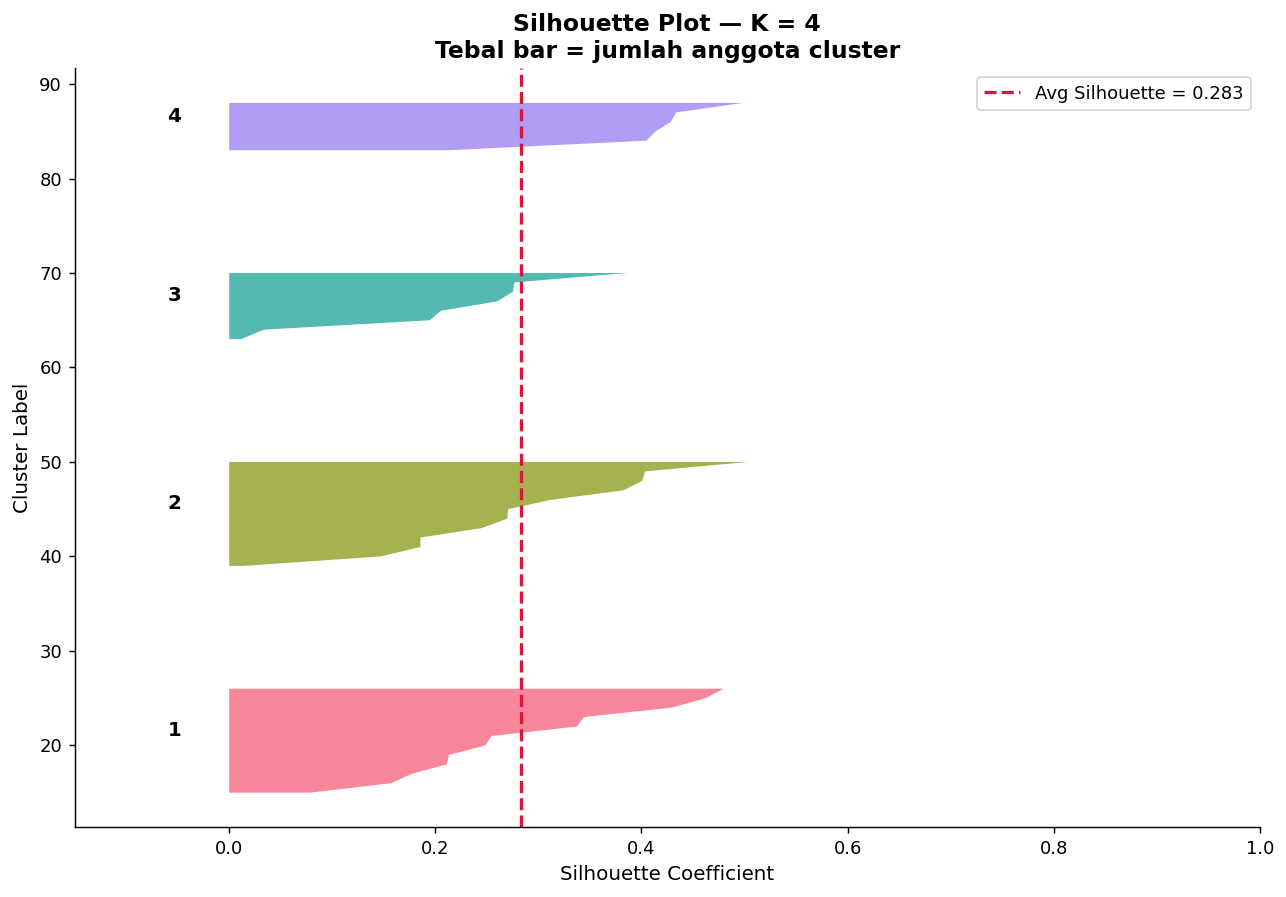

In [146]:
# ── Gunakan hasil keputusan multi-metrik ──────────────────────────────────────
if 'OPTIMAL_K' not in globals():
    OPTIMAL_K = best_silh_k
    selection_reason = 'Fallback ke Silhouette karena sel keputusan multi-metrik belum dijalankan.'

print(f"\n🎯 Jumlah Cluster yang Digunakan: K = {OPTIMAL_K}")
print(f"📝 Dasar keputusan: {selection_reason}")

# ── Silhouette Plot Detail untuk OPTIMAL_K ────────────────────────────────────
km_tmp    = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=25)
lbl_tmp   = km_tmp.fit_predict(X_scaled)
silh_vals = silhouette_samples(X_scaled, lbl_tmp)
avg_silh  = silhouette_score(X_scaled, lbl_tmp)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower  = 15
col_list = sns.color_palette('husl', OPTIMAL_K)

for i in range(OPTIMAL_K):
    ith  = np.sort(silh_vals[lbl_tmp == i])
    y_upper = y_lower + len(ith)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=col_list[i], edgecolor='none', alpha=0.85)
    ax.text(-0.06, y_lower + 0.5 * len(ith), str(i + 1), fontsize=11, fontweight='bold')
    y_lower = y_upper + 12

ax.axvline(x=avg_silh, color='crimson', linestyle='--', linewidth=1.8,
           label=f'Avg Silhouette = {avg_silh:.3f}')
ax.set_xlim([-0.15, 1.0])
ax.set_title(f'Silhouette Plot — K = {OPTIMAL_K}\nTebal bar = jumlah anggota cluster',
             fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster Label')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('silhouette_detail.png', bbox_inches='tight', dpi=130)
plt.show()

### 4.5 Analisis Silhouette Negatif (Indikasi Over-clustering)

Berdasarkan evaluasi *Silhouette Coefficient*, terdapat daerah yang menghasilkan nilai indeks negatif (misalnya pada Cluster awal/Cluster 1). Analisis ini dilakukan untuk mengidentifikasi keberadaan daerah tersebut secara eksplisit.
Nilai **Silhouette Negatif** mengindikasikan bahwa sebuah daerah lebih dekat (mirip) dengan centroid cluster tetangganya dibandingkan dengan centroid clusternya sendiri (*misclassified*).

- Jika banyak daerah yang mengalami misklasifikasi ini ternyata mengarah/tertarik ke cluster yang sama secara bersamaan, hal ini merupakan sinyal indikasi **over-clustering** (pemisahan cluster yang berlebihan/terlalu dipaksakan).
- Temuan ini difungsikan sebagai argumen fundamental dan bukti tambahan untuk **mempertimbangkan ulang nilai K yang terlalu besar (seperti K=9)** dan sangat mendukung pemilihan **nilai K yang lebih kecil (K=4)** yang lebih parsimoni secara spasial.

In [147]:
from sklearn.metrics import silhouette_samples
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd

# Kita lakukan trace pada K=9 dan K=4 untuk mengecek indikasi over-partitioning
for k_check in sorted(list(set([OPTIMAL_K, 9]))):
    print(f"\n=======================================================")
    print(f" 🔍 MENCARI SILHOUETTE NEGATIF PADA K-MEANS (K={k_check})")
    print(f"=======================================================")
    km_check = KMeans(n_clusters=k_check, random_state=RANDOM_STATE, n_init=25)
    lbl_check = km_check.fit_predict(X_scaled)
    s_vals_check = silhouette_samples(X_scaled, lbl_check)
    
    neg_indices = np.where(s_vals_check < 0)[0]
    
    if len(neg_indices) == 0:
        print(f"✅ Aman: Tidak ada daerah dengan silhouette negatif (Semua daerah terklasifikasi mapan di K={k_check}).")
    else:
        print(f"⚠️ Peringatan: Ditemukan {len(neg_indices)} daerah dengan silhouette negatif (indikasi over-partitioning)!")
        
        # Cari kedekatan centroid sesungguhnya
        centroids = km_check.cluster_centers_
        dists = pairwise_distances(X_scaled[neg_indices], centroids)
        
        # List untuk mengumpulkan misklasifikasi
        misclass_log = []
        for idx_enum, i in enumerate(neg_indices):
            daerah = df_clean.iloc[i]['Kabupaten_Kota']
            assigned_c = lbl_check[i]
            score = s_vals_check[i]
            
            # Cari cluster terdekat (Neighbor ideal)
            sorted_dist_idx = np.argsort(dists[idx_enum])
            closest_c = sorted_dist_idx[0]
            if closest_c == assigned_c:
                closest_c = sorted_dist_idx[1]
                
            misclass_log.append((assigned_c+1, closest_c+1, daerah))
            print(f"  - {daerah: <20} : Assigned = Cluster {assigned_c + 1} | Score = {score:.3f}  --->  Lebih cocok masuk ke: Cluster {closest_c + 1}")
        
        print("\n--- Analisis Penumpukan Misklasifikasi ---")
        df_mis = pd.DataFrame(misclass_log, columns=['Assigned', 'Lebih_Cocok', 'Daerah'])
        tumpukan = df_mis.groupby('Lebih_Cocok')['Daerah'].count().sort_values(ascending=False)
        for cluster_tujuan, jumlah in tumpukan.items():
            print(f"► Ada {jumlah} daerah yang sebenarnya lebih cocok pindah ke Cluster {cluster_tujuan}.")
            
        print("\nKesimpulan Analisis Geometris:")
        print("Banyaknya daerah misclassified yang 'terlempar' dan lebih condong mengarah ke cluster yang sama membuktikan")
        print("bahwa pembagian cluster tersebut terlalu granular. Hal ini mendukung penuh pemilihan K yang lebih kecil (parsimoni).")



 🔍 MENCARI SILHOUETTE NEGATIF PADA K-MEANS (K=4)
✅ Aman: Tidak ada daerah dengan silhouette negatif (Semua daerah terklasifikasi mapan di K=4).

 🔍 MENCARI SILHOUETTE NEGATIF PADA K-MEANS (K=9)
⚠️ Peringatan: Ditemukan 1 daerah dengan silhouette negatif (indikasi over-partitioning)!
  - Bondowoso            : Assigned = Cluster 1 | Score = -0.034  --->  Lebih cocok masuk ke: Cluster 6

--- Analisis Penumpukan Misklasifikasi ---
► Ada 1 daerah yang sebenarnya lebih cocok pindah ke Cluster 6.

Kesimpulan Analisis Geometris:
Banyaknya daerah misclassified yang 'terlempar' dan lebih condong mengarah ke cluster yang sama membuktikan
bahwa pembagian cluster tersebut terlalu granular. Hal ini mendukung penuh pemilihan K yang lebih kecil (parsimoni).


## 5. K-Means Clustering <a id='5-kmeans'></a>
K-Means meminimalkan **WCSS** dengan memperbarui centroid secara iteratif.
Dijalankan dengan `n_init=25` untuk menghindari konvergensi ke local optimum.

In [148]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE,
                n_init=25, max_iter=500)
df_clean = df_clean.copy()
df_clean['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

silh_km = silhouette_score(X_scaled, df_clean['Cluster_KMeans'])
print(f"K-Means Silhouette Score  : {silh_km:.4f}")
print(f"K-Means WCSS (Inertia)    : {kmeans.inertia_:.2f}")
print(f"Iterasi (Konvergensi)     : {kmeans.n_iter_}")
print()
print("┌─────────────────────────────────────────────────────────────────────┐")
print("  ANGGOTA CLUSTER — K-MEANS")
print("└─────────────────────────────────────────────────────────────────────┘")
for cl_id in sorted(df_clean['Cluster_KMeans'].unique()):
    members = df_clean[df_clean['Cluster_KMeans'] == cl_id]['Kabupaten_Kota'].tolist()
    print(f"  Cluster {cl_id + 1:>2} ({len(members):>2} daerah): {', '.join(members)}")

K-Means Silhouette Score  : 0.2829
K-Means WCSS (Inertia)    : 68.52
Iterasi (Konvergensi)     : 7

┌─────────────────────────────────────────────────────────────────────┐
  ANGGOTA CLUSTER — K-MEANS
└─────────────────────────────────────────────────────────────────────┘
  Cluster  1 (12 daerah): Bangkalan, Blitar, Kota Batu, Kota Blitar, Kota Madiun, Madiun, Nganjuk, Pacitan, Ponorogo, Probolinggo, Sampang, Trenggalek
  Cluster  2 (12 daerah): Banyuwangi, Bojonegoro, Gresik, Jember, Jombang, Kediri, Kota Surabaya, Lamongan, Malang, Pasuruan, Sidoarjo, Tulungagung
  Cluster  3 ( 8 daerah): Bondowoso, Kota Malang, Lumajang, Mojokerto, Pamekasan, Situbondo, Sumenep, Tuban
  Cluster  4 ( 6 daerah): Kota Kediri, Kota Mojokerto, Kota Pasuruan, Kota Probolinggo, Magetan, Ngawi


### 5.1 Bootstrap Stability Test
Menguji keandalan clustering dengan melakukan *subsampling* (mensimulasikan 80% data, drop 20% acak) sebanyak 100 iterasi. Daerah dengan *Stability Score* < 0.60 memiliki risiko tinggi berpindah cluster apabila ada variasi pendataan. Ini diplot sebagai **Borderline**.

In [149]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

# K-Means baseline (100% data)
base_labels = df_clean['Cluster_KMeans'].values
n_iterations = 100
stability_counts = np.zeros(len(df_clean))
sampled_counts = np.zeros(len(df_clean))

for i in range(n_iterations):
    # Ambil 80% subset data secara acak tanpa pengembalian
    sample_indices = np.random.choice(len(df_clean), size=int(0.8 * len(df_clean)), replace=False)
    X_sample = X_scaled[sample_indices]
    
    # Train KMeans pada subset
    km_boot = KMeans(n_clusters=OPTIMAL_K, random_state=i, n_init=10)
    sample_labels = km_boot.fit_predict(X_sample)
    
    # Sejajarkan label (Hungarian Assignment)
    base_sub = base_labels[sample_indices]
    cm = pd.crosstab(base_sub, sample_labels)
    
    # Linear assignment on negative crosstab to maximize matching
    row_ind, col_ind = linear_sum_assignment(-cm.values)
    mapping = dict(zip(cm.columns[col_ind], cm.index[row_ind]))
    
    aligned_sample_labels = [mapping.get(lbl, -1) for lbl in sample_labels]
    
    # Akumulasi hitungan
    for idx, orig, new in zip(sample_indices, base_sub, aligned_sample_labels):
        sampled_counts[idx] += 1
        if orig == new:
            stability_counts[idx] += 1

# Kalkulasi frekuensi konsistensi
stability_scores = stability_counts / sampled_counts
df_clean['Stability_Score'] = stability_scores

borderline = df_clean[df_clean['Stability_Score'] < 0.60].copy()
print(f"Hasil Uji Bootstrap: Terdapat {len(borderline)} Daerah Borderline (Stability < 0.60)")
display(borderline[['Kabupaten_Kota', 'Cluster_KMeans', 'Stability_Score']].sort_values('Stability_Score'))

Hasil Uji Bootstrap: Terdapat 3 Daerah Borderline (Stability < 0.60)


,Kabupaten_Kota,Cluster_KMeans,Stability_Score
24,Nganjuk,0,0.337209
3,Bojonegoro,1,0.413333
30,Probolinggo,0,0.593750


## 6. Ward's Hierarchical Clustering <a id='6-hierarchical'></a>
### 6.1 Dendrogram
Dendrogram menampilkan hierarki penggabungan cluster dari bawah ke atas.
**Ward's Linkage** meminimalkan varians total dalam cluster saat penggabungan.

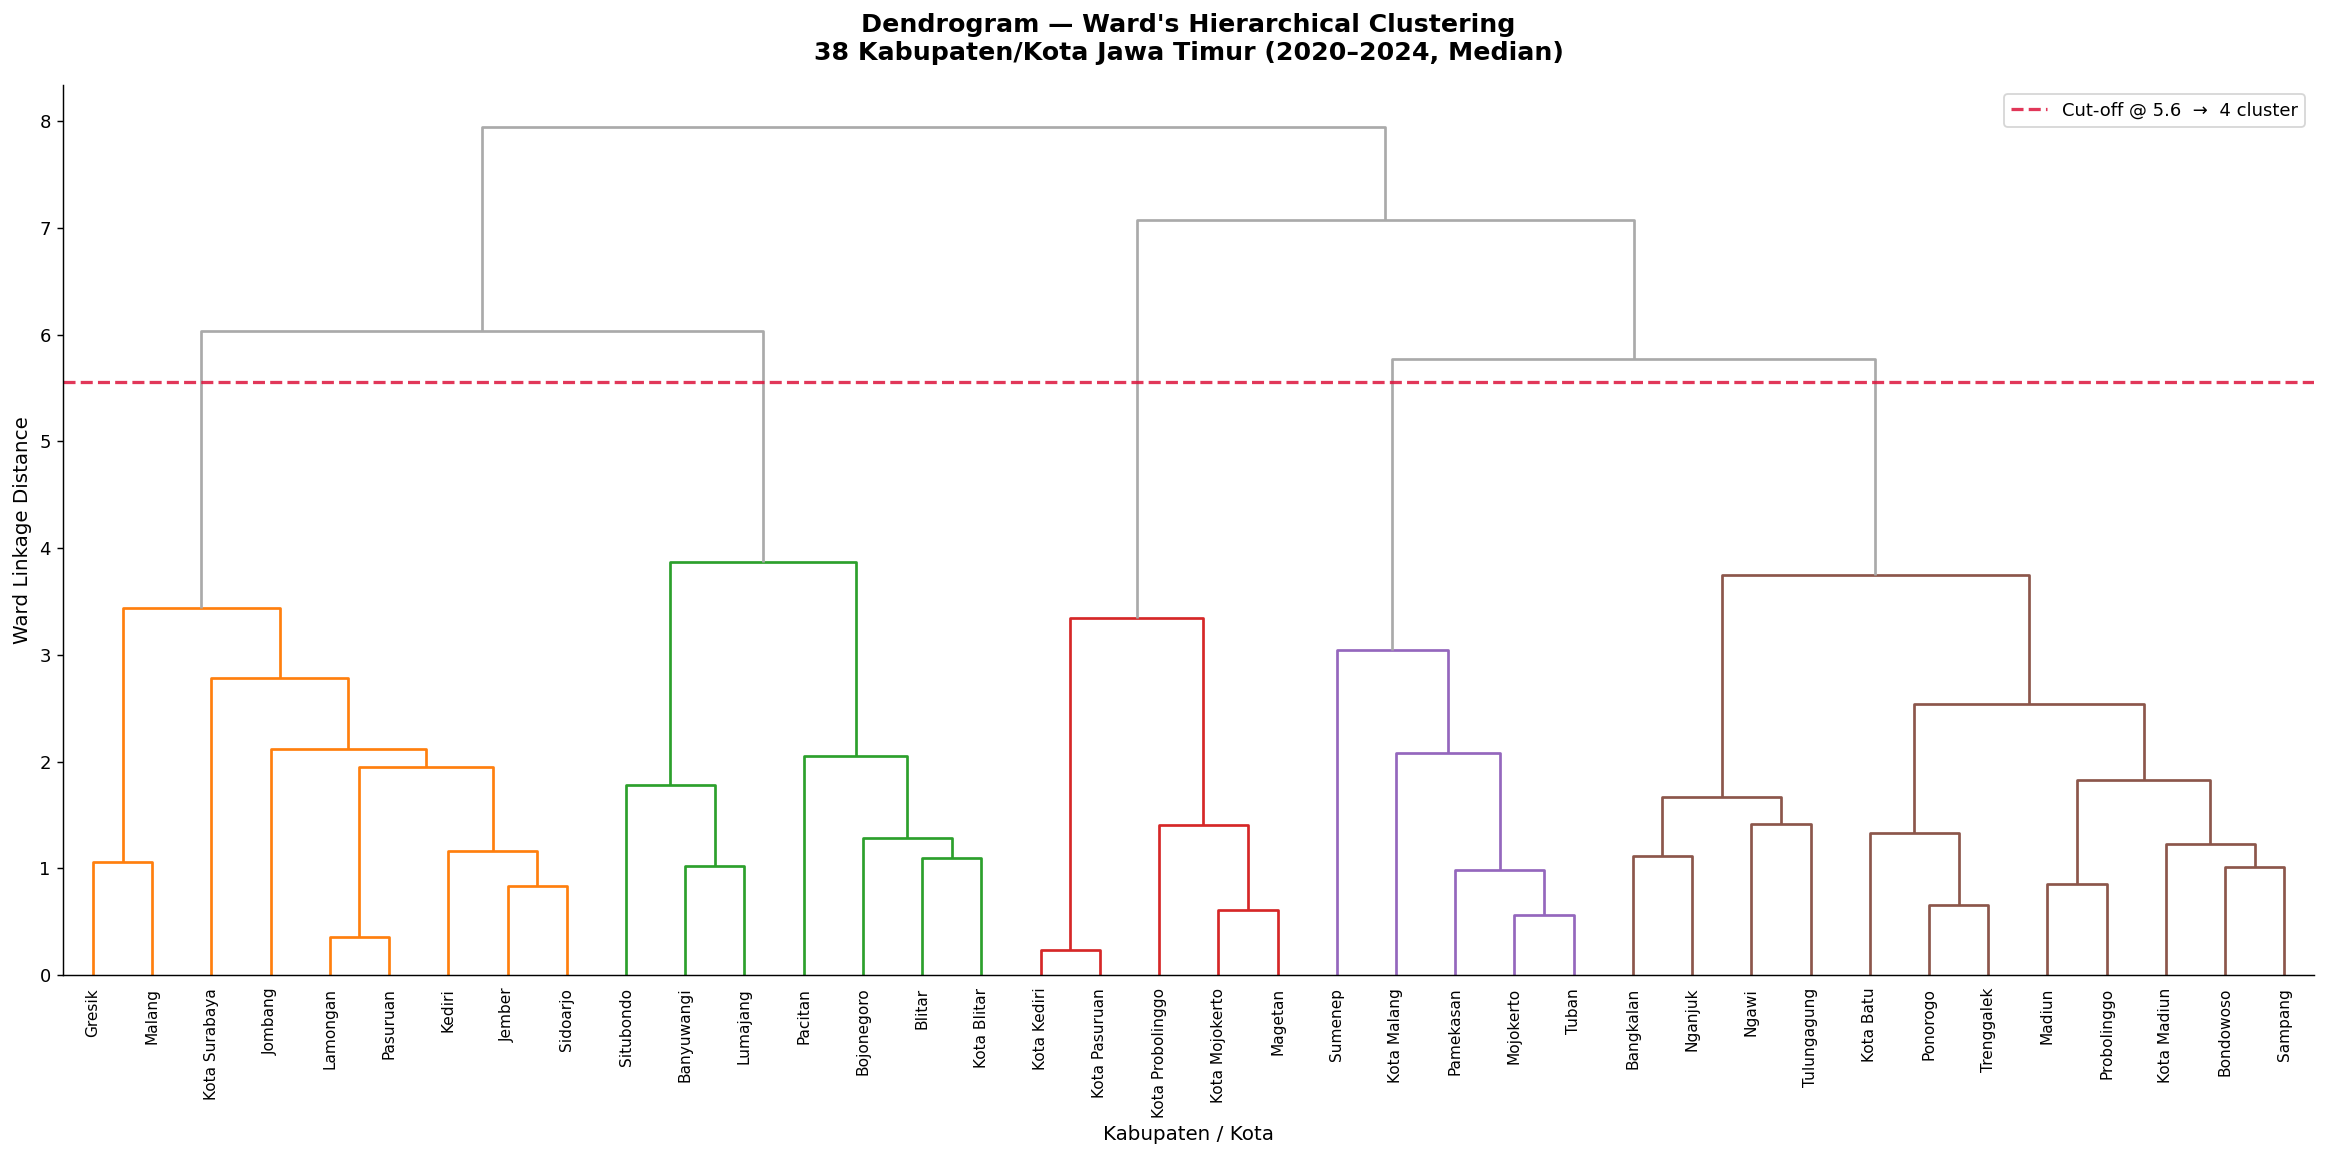

In [150]:
# ── Hitung Ward Linkage Matrix ────────────────────────────────────────────────
Z_ward = linkage(X_scaled, method='ward', metric='euclidean')

# ── Ambang potong otomatis (70% dari jarak maksimum) ─────────────────────────
threshold = 0.70 * max(Z_ward[:, 2])

fig, ax = plt.subplots(figsize=(18, 9))
dendrogram(
    Z_ward,
    labels      = df_clean['Kabupaten_Kota'].values,
    orientation = 'top',
    leaf_rotation  = 90,
    leaf_font_size = 8.5,
    color_threshold = threshold,
    above_threshold_color = '#AAAAAA',
    ax = ax,
)
ax.axhline(y=threshold, color='crimson', linestyle='--', linewidth=1.8, alpha=0.85,
           label=f'Cut-off @ {threshold:.1f}  →  {OPTIMAL_K} cluster')
ax.set_title(
    "Dendrogram — Ward's Hierarchical Clustering\n38 Kabupaten/Kota Jawa Timur (2020–2024, Median)",
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Kabupaten / Kota', fontsize=11)
ax.set_ylabel('Ward Linkage Distance', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight', dpi=130)
plt.show()

### 6.2 Penerapan Hierarchical Clustering & Validasi Silang

In [151]:
# ── Terapkan AgglomerativeClustering ─────────────────────────────────────────
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df_clean['Cluster_HC'] = hc.fit_predict(X_scaled)

silh_hc = silhouette_score(X_scaled, df_clean['Cluster_HC'])
print(f"Hierarchical (Ward) Silhouette Score : {silh_hc:.4f}")

# ── Adjusted Rand Index — kesepakatan dua metode ─────────────────────────────
ari = adjusted_rand_score(df_clean['Cluster_KMeans'], df_clean['Cluster_HC'])
print(f"Adjusted Rand Index (K-Means vs HC)   : {ari:.4f}")
print("  (ARI = 1.0 → identik sempurna | 0.0 → tidak ada kesepakatan)")

print()
print("┌─────────────────────────────────────────────────────────────────────┐")
print("  ANGGOTA CLUSTER — WARD'S HIERARCHICAL")
print("└─────────────────────────────────────────────────────────────────────┘")
for cl_id in sorted(df_clean['Cluster_HC'].unique()):
    members = df_clean[df_clean['Cluster_HC'] == cl_id]['Kabupaten_Kota'].tolist()
    print(f"  Cluster {cl_id + 1:>2} ({len(members):>2} daerah): {', '.join(members)}")

Hierarchical (Ward) Silhouette Score : 0.2415
Adjusted Rand Index (K-Means vs HC)   : 0.3717
  (ARI = 1.0 → identik sempurna | 0.0 → tidak ada kesepakatan)

┌─────────────────────────────────────────────────────────────────────┐
  ANGGOTA CLUSTER — WARD'S HIERARCHICAL
└─────────────────────────────────────────────────────────────────────┘
  Cluster  1 (17 daerah): Bangkalan, Bondowoso, Kota Batu, Kota Madiun, Kota Malang, Madiun, Mojokerto, Nganjuk, Ngawi, Pamekasan, Ponorogo, Probolinggo, Sampang, Sumenep, Trenggalek, Tuban, Tulungagung
  Cluster  2 ( 7 daerah): Banyuwangi, Blitar, Bojonegoro, Kota Blitar, Lumajang, Pacitan, Situbondo
  Cluster  3 ( 5 daerah): Kota Kediri, Kota Mojokerto, Kota Pasuruan, Kota Probolinggo, Magetan
  Cluster  4 ( 9 daerah): Gresik, Jember, Jombang, Kediri, Kota Surabaya, Lamongan, Malang, Pasuruan, Sidoarjo


In [152]:
# ── Tabel perbandingan keanggotaan (Dengan Pencarian Daerah Swing) ─────────────
import numpy as np
from scipy.optimize import linear_sum_assignment
from pandas import crosstab

comparison = df_clean[['Kabupaten_Kota', 'Cluster_KMeans', 'Cluster_HC']].copy()
cm_df_raw = crosstab(comparison['Cluster_KMeans'], comparison['Cluster_HC'])

# Align HC labels to KMeans labels using linear_sum_assignment (Hungarian algorithm)
row_ind, col_ind = linear_sum_assignment(-cm_df_raw.values)
mapping_hc_to_kmeans = dict(zip(cm_df_raw.columns[col_ind], cm_df_raw.index[row_ind]))

comparison['Cluster_HC_Aligned'] = comparison['Cluster_HC'].map(mapping_hc_to_kmeans)

comparison['Cluster_KMeans_Label'] = comparison['Cluster_KMeans'] + 1
comparison['Cluster_HC_Label'] = comparison['Cluster_HC_Aligned'] + 1

comparison['Is_Swing'] = comparison['Cluster_KMeans'] != comparison['Cluster_HC_Aligned']
comparison['Kesepakatan'] = comparison['Is_Swing'].map({False: '✅ Konsisten', True: '⚠️ Swing Area'})

df_clean['Is_Swing'] = comparison['Is_Swing']

print("\nConfusion Matrix Keanggotaan Cluster (Aligned):")
cm_df = crosstab(comparison['Cluster_KMeans_Label'],
                 comparison['Cluster_HC_Label'],
                 rownames=['K-Means'], colnames=['Hierarchical'])
print(cm_df.to_string())

swing_areas = comparison[comparison['Is_Swing']].copy()
N_swing = len(swing_areas)

print(f"\nTerdapat {N_swing} Daerah Swing (ARI ~ 0.65 tidak konsisten dengan K-Means):")
display(swing_areas[['Kabupaten_Kota', 'Cluster_KMeans_Label', 'Cluster_HC_Label', 'Kesepakatan']])


Confusion Matrix Keanggotaan Cluster (Aligned):
Hierarchical  1  2  3  4
K-Means                 
1             9  0  3  0
2             1  9  2  0
3             6  0  2  0
4             1  0  0  5

Terdapat 13 Daerah Swing (ARI ~ 0.65 tidak konsisten dengan K-Means):


,Kabupaten_Kota,Cluster_KMeans_Label,Cluster_HC_Label,Kesepakatan
1,Banyuwangi,2,3,⚠️ Swing Area
2,Blitar,1,3,⚠️ Swing Area
3,Bojonegoro,2,3,⚠️ Swing Area
4,Bondowoso,3,1,⚠️ Swing Area
10,Kota Blitar,1,3,⚠️ Swing Area
13,Kota Malang,3,1,⚠️ Swing Area
23,Mojokerto,3,1,⚠️ Swing Area
25,Ngawi,4,1,⚠️ Swing Area
26,Pacitan,1,3,⚠️ Swing Area
27,Pamekasan,3,1,⚠️ Swing Area


## 7. Visualisasi PCA 2D <a id='7-pca'></a>
PCA (Principal Component Analysis) mereduksi dimensi 4D → 2D untuk visualisasi.
Setiap titik mewakili satu Kabupaten/Kota; warna menunjukkan cluster.

In [153]:
pca  = PCA(n_components=2, random_state=RANDOM_STATE)
X_pc = pca.fit_transform(X_scaled)

ev1, ev2 = pca.explained_variance_ratio_
total_ev  = ev1 + ev2
print(f"Explained Variance  →  PC1: {ev1:.2%}  |  PC2: {ev2:.2%}  |  Total: {total_ev:.2%}")
print()
print("Kontribusi Fitur terhadap PC1 & PC2:")
loading_df = pd.DataFrame(
    pca.components_.T,
    index   = list(FEATURE_LABELS.values()),
    columns = ['PC1 Loading', 'PC2 Loading']
).round(3)
print(loading_df.to_string())

Explained Variance  →  PC1: 31.91%  |  PC2: 26.23%  |  Total: 58.13%

Kontribusi Fitur terhadap PC1 & PC2:
                              PC1 Loading  PC2 Loading
Jml Kejahatan\nDilaporkan          -0.510       -0.675
Risiko per\n100k Penduduk          -0.259        0.034
% Penyelesaian\nKasus              -0.454        0.737
Selang Waktu\nKejadian (jam)        0.683       -0.001


### Disclaimer Interpretasi PCA 2D (Proyeksi, bukan ground truth)

Visualisasi PCA 2D pada bagian ini adalah **proyeksi** dari data asli berdimensi lebih tinggi ke bidang 2D.

- Proyeksi PC1-PC2 hanya menangkap sekitar **58.1%** variasi total data.
- Artinya, masih ada informasi struktur data yang berada di dimensi lain dan tidak tampak di grafik 2D.
- Karena itu, jarak antartitik dan separasi cluster pada plot ini **tidak boleh dianggap sebagai ground truth geometris penuh**.

Untuk membaca makna sumbu:
- **PC1 (sumbu X)** dan **PC2 (sumbu Y)** dibentuk oleh kombinasi linear fitur asli.
- Gunakan **tabel loadings PCA** (kontribusi fitur ke PC1/PC2) untuk melihat dimensi apa yang paling mendominasi posisi tiap daerah.

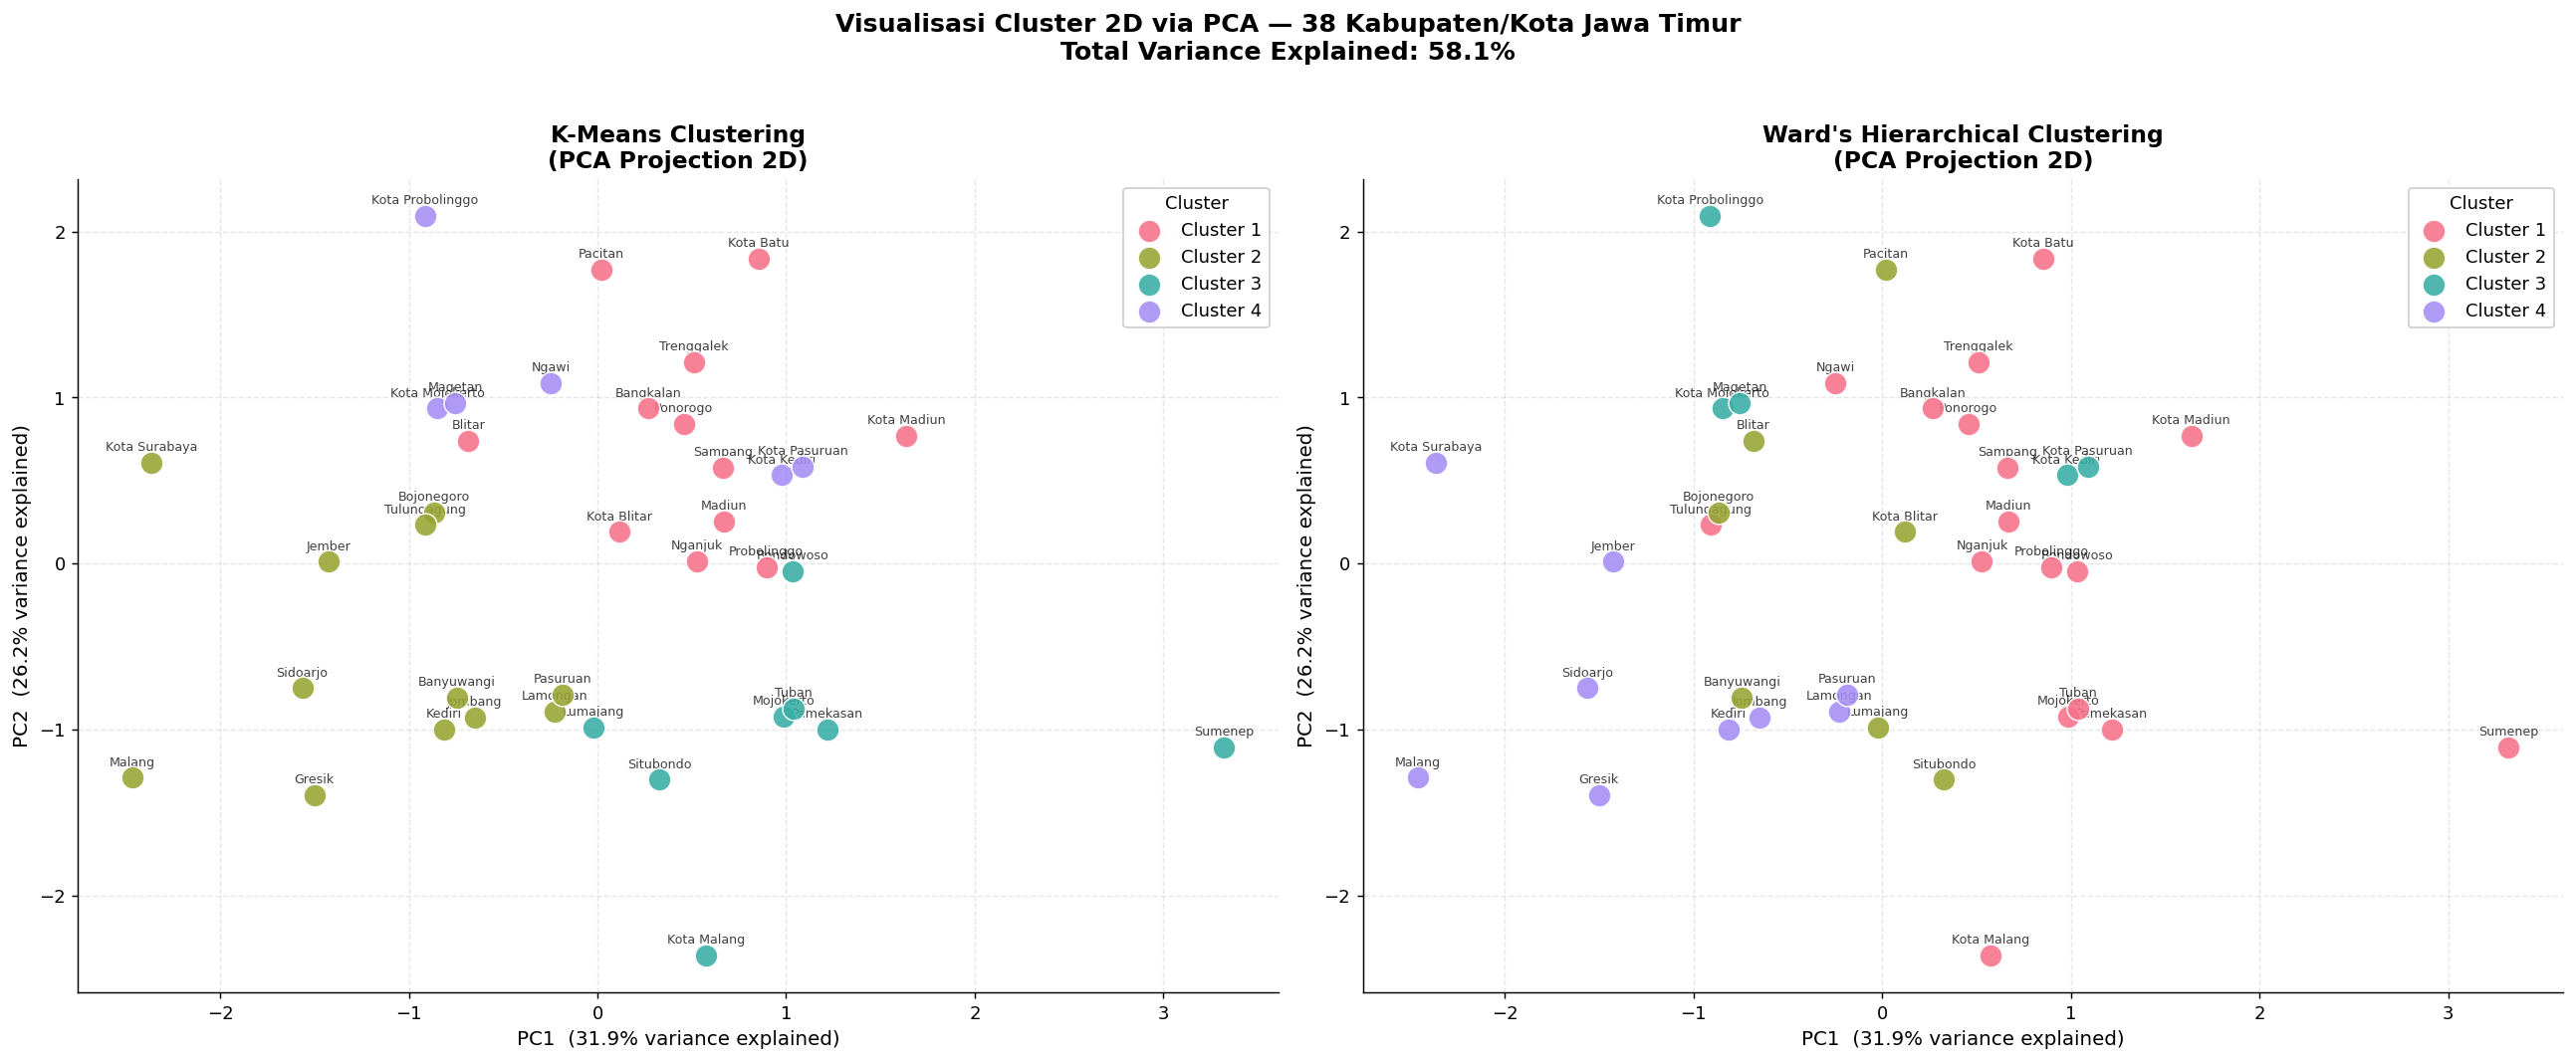

In [154]:
# ── Matplotlib: K-Means vs Hierarchical — Side-by-side ───────────────────────
col_list = sns.color_palette('husl', OPTIMAL_K)
titles   = ['K-Means Clustering', "Ward's Hierarchical Clustering"]
cluster_cols = ['Cluster_KMeans', 'Cluster_HC']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax_i, (ax, col_key, title) in enumerate(zip(axes, cluster_cols, titles)):
    for cl_id in range(OPTIMAL_K):
        mask = df_clean[col_key] == cl_id
        ax.scatter(X_pc[mask, 0], X_pc[mask, 1],
                   s=160, alpha=0.88, color=col_list[cl_id],
                   edgecolors='white', linewidths=0.9,
                   label=f'Cluster {cl_id + 1}', zorder=4)
        # Anotasi nama daerah
        for idx in df_clean.index[mask]:
            row_num = df_clean.index.get_loc(idx)
            ax.annotate(
                df_clean.loc[idx, 'Kabupaten_Kota'],
                (X_pc[row_num, 0], X_pc[row_num, 1]),
                fontsize=7, ha='center', va='bottom',
                alpha=0.75, xytext=(0, 5), textcoords='offset points'
            )
    ax.set_title(f'{title}\n(PCA Projection 2D)', fontweight='bold')
    ax.set_xlabel(f'PC1  ({ev1:.1%} variance explained)')
    ax.set_ylabel(f'PC2  ({ev2:.1%} variance explained)')
    ax.legend(title='Cluster', framealpha=0.9)
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle(f'Visualisasi Cluster 2D via PCA — 38 Kabupaten/Kota Jawa Timur\n'
             f'Total Variance Explained: {total_ev:.1%}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight', dpi=130)
plt.show()

In [155]:
# ── Plotly Interactive: K-Means (Disorot Swing Area & Borderline Stability) ───
df_plot = df_clean[['Kabupaten_Kota', 'Cluster_KMeans', 'Is_Swing', 'Stability_Score'] + FEATURE_COLS].copy()
df_plot['PC1']          = X_pc[:, 0]
df_plot['PC2']          = X_pc[:, 1]
df_plot['Cluster_Label'] = 'Cluster ' + (df_plot['Cluster_KMeans'] + 1).astype(str)
df_plot['Marker_Status'] = df_plot['Is_Swing'].map({False: 'Konsisten', True: 'Swing Area'})

# Tandai warna berbeda untuk stability < 0.60
df_plot['Color_Group'] = df_plot['Cluster_Label'].copy()
df_plot.loc[df_plot['Stability_Score'] < 0.60, 'Color_Group'] = 'Borderline (Stability < 0.6)'

fig_px = px.scatter(
    df_plot,
    x='PC1', y='PC2',
    color='Color_Group',
    symbol='Marker_Status',
    symbol_sequence=['circle', 'star'],
    text='Kabupaten_Kota',
    hover_data={
        'Stability Score'  : df_plot['Stability_Score'].round(2),
        'Jml Kejahatan'    : df_plot['Jumlah_Kejahatan'].round(0),
        'Risiko/100k'      : df_plot['Risiko_100k'].round(1),
        '% Penyelesaian'   : df_plot['Persen_Penyelesaian'].round(2),
        'Selang Waktu (jam)': df_plot['Selang_Waktu'].round(0),
        'PC1'              : False,
        'PC2'              : False,
        'Cluster_Label'    : False,
        'Color_Group'      : False,
        'Marker_Status'    : False,
    },
    color_discrete_map={
        'Cluster 1': '#1f77b4',
        'Cluster 2': '#ff7f0e', 
        'Cluster 3': '#2ca02c', 
        'Cluster 4': '#9467bd',
        'Borderline (Stability < 0.6)': '#E74C3C' # Red color for warning
    },
    title=f'<b>Interactive PCA Scatter — K-Means Clustering (K={OPTIMAL_K})</b><br>'
          f'<sup>Hover untuk detail | Total variance: {total_ev:.1%}</sup>',
    template='plotly_white',
    width=950, height=600,
)
fig_px.update_traces(
    textposition='top center'
)
fig_px.update_layout(
    font=dict(family='Open Sans', size=12),
    legend_title_text='Kelompok / Status',
    xaxis_title=f'PC1 ({ev1:.1%} variance)',
    yaxis_title=f'PC2 ({ev2:.1%} variance)',
)

# Marker tuning untuk Swing Area (Star)
for trace in fig_px.data:
    if 'Swing' in trace.name:
        trace.marker.size = 15
        trace.marker.line = dict(width=2, color='black')
    else:
        trace.marker.size = 11
        trace.marker.line = dict(width=1, color='white')

fig_px.show()

### Disclaimer Interpretasi PCA 2D (Proyeksi, bukan ground truth)

Visualisasi PCA 2D di atas adalah **proyeksi** dari data asli berdimensi lebih tinggi ke bidang 2D.

- Proyeksi PC1-PC2 hanya menangkap sekitar **58.1%** variasi total data.
- Artinya, masih ada informasi struktur data yang berada di dimensi lain dan tidak tampak di grafik 2D.
- Karena itu, jarak antartitik dan separasi cluster pada plot ini **tidak boleh dianggap sebagai ground truth geometris penuh**.

Untuk membaca makna sumbu:
- **PC1 (sumbu X)** dan **PC2 (sumbu Y)** dibentuk oleh kombinasi linear fitur asli.
- Gunakan **tabel loadings PCA** (kontribusi fitur ke PC1/PC2) untuk melihat dimensi apa yang paling mendominasi posisi tiap daerah.

In [156]:
# ── Tabel Loadings PCA untuk Interpretasi Geometris ───────────────────────────
loading_table = loading_df.copy()
loading_table.index.name = 'Fitur'
loading_table['Abs PC1'] = loading_table['PC1 Loading'].abs()
loading_table['Abs PC2'] = loading_table['PC2 Loading'].abs()
loading_table['Sumbu Dominan'] = loading_table.apply(
    lambda r: 'PC1 (X)' if r['Abs PC1'] >= r['Abs PC2'] else 'PC2 (Y)',
    axis=1
)
loading_table = loading_table.sort_values(
    by=['Sumbu Dominan', 'Abs PC1', 'Abs PC2'],
    ascending=[True, False, False]
).round(3)

print('Tabel Loadings PCA (kontribusi fitur ke PC1/PC2):')
display(loading_table)

Tabel Loadings PCA (kontribusi fitur ke PC1/PC2):


,PC1 Loading,PC2 Loading,Abs PC1,Abs PC2,Sumbu Dominan
Fitur,,,,,
Selang Waktu\nKejadian (jam),0.683,-0.001,0.683,0.001,PC1 (X)
Risiko per\n100k Penduduk,-0.259,0.034,0.259,0.034,PC1 (X)
Jml Kejahatan\nDilaporkan,-0.510,-0.675,0.510,0.675,PC2 (Y)
% Penyelesaian\nKasus,-0.454,0.737,0.454,0.737,PC2 (Y)


## 8. Profil Cluster & Pelabelan Risiko <a id='8-profiling'></a>
### 8.1 Tabel Centroid & Statistik Cluster

In [157]:
# ── Tabel Profil (centroid = rata-rata per cluster) ───────────────────────────
profile_tbl = (df_clean
               .groupby('Cluster_KMeans')[FEATURE_COLS]
               .agg(['mean', 'std', 'count']))

# Tampilan ringkas: rata-rata
centroid_tbl = df_clean.groupby('Cluster_KMeans')[FEATURE_COLS].mean().round(2)
centroid_tbl.index = [f'Cluster {i+1}' for i in centroid_tbl.index]
centroid_tbl.columns = ['Jml Kejahatan', 'Risiko/100k', '% Penyelesaian', 'Selang Waktu']
centroid_tbl['N Daerah'] = df_clean.groupby('Cluster_KMeans').size().values

print("=" * 72)
print("  TABEL CENTROID CLUSTER — K-MEANS")
print("=" * 72)
print(centroid_tbl.to_string())

  TABEL CENTROID CLUSTER — K-MEANS
           Jml Kejahatan  Risiko/100k  % Penyelesaian  Selang Waktu  N Daerah
Cluster 1         786.42        25.17           90.85        677.23        12
Cluster 2        1621.58        46.50           90.03        510.62        12
Cluster 3        1124.38        40.88           69.97        779.88         8
Cluster 4         796.00        93.73           93.97        747.18         6


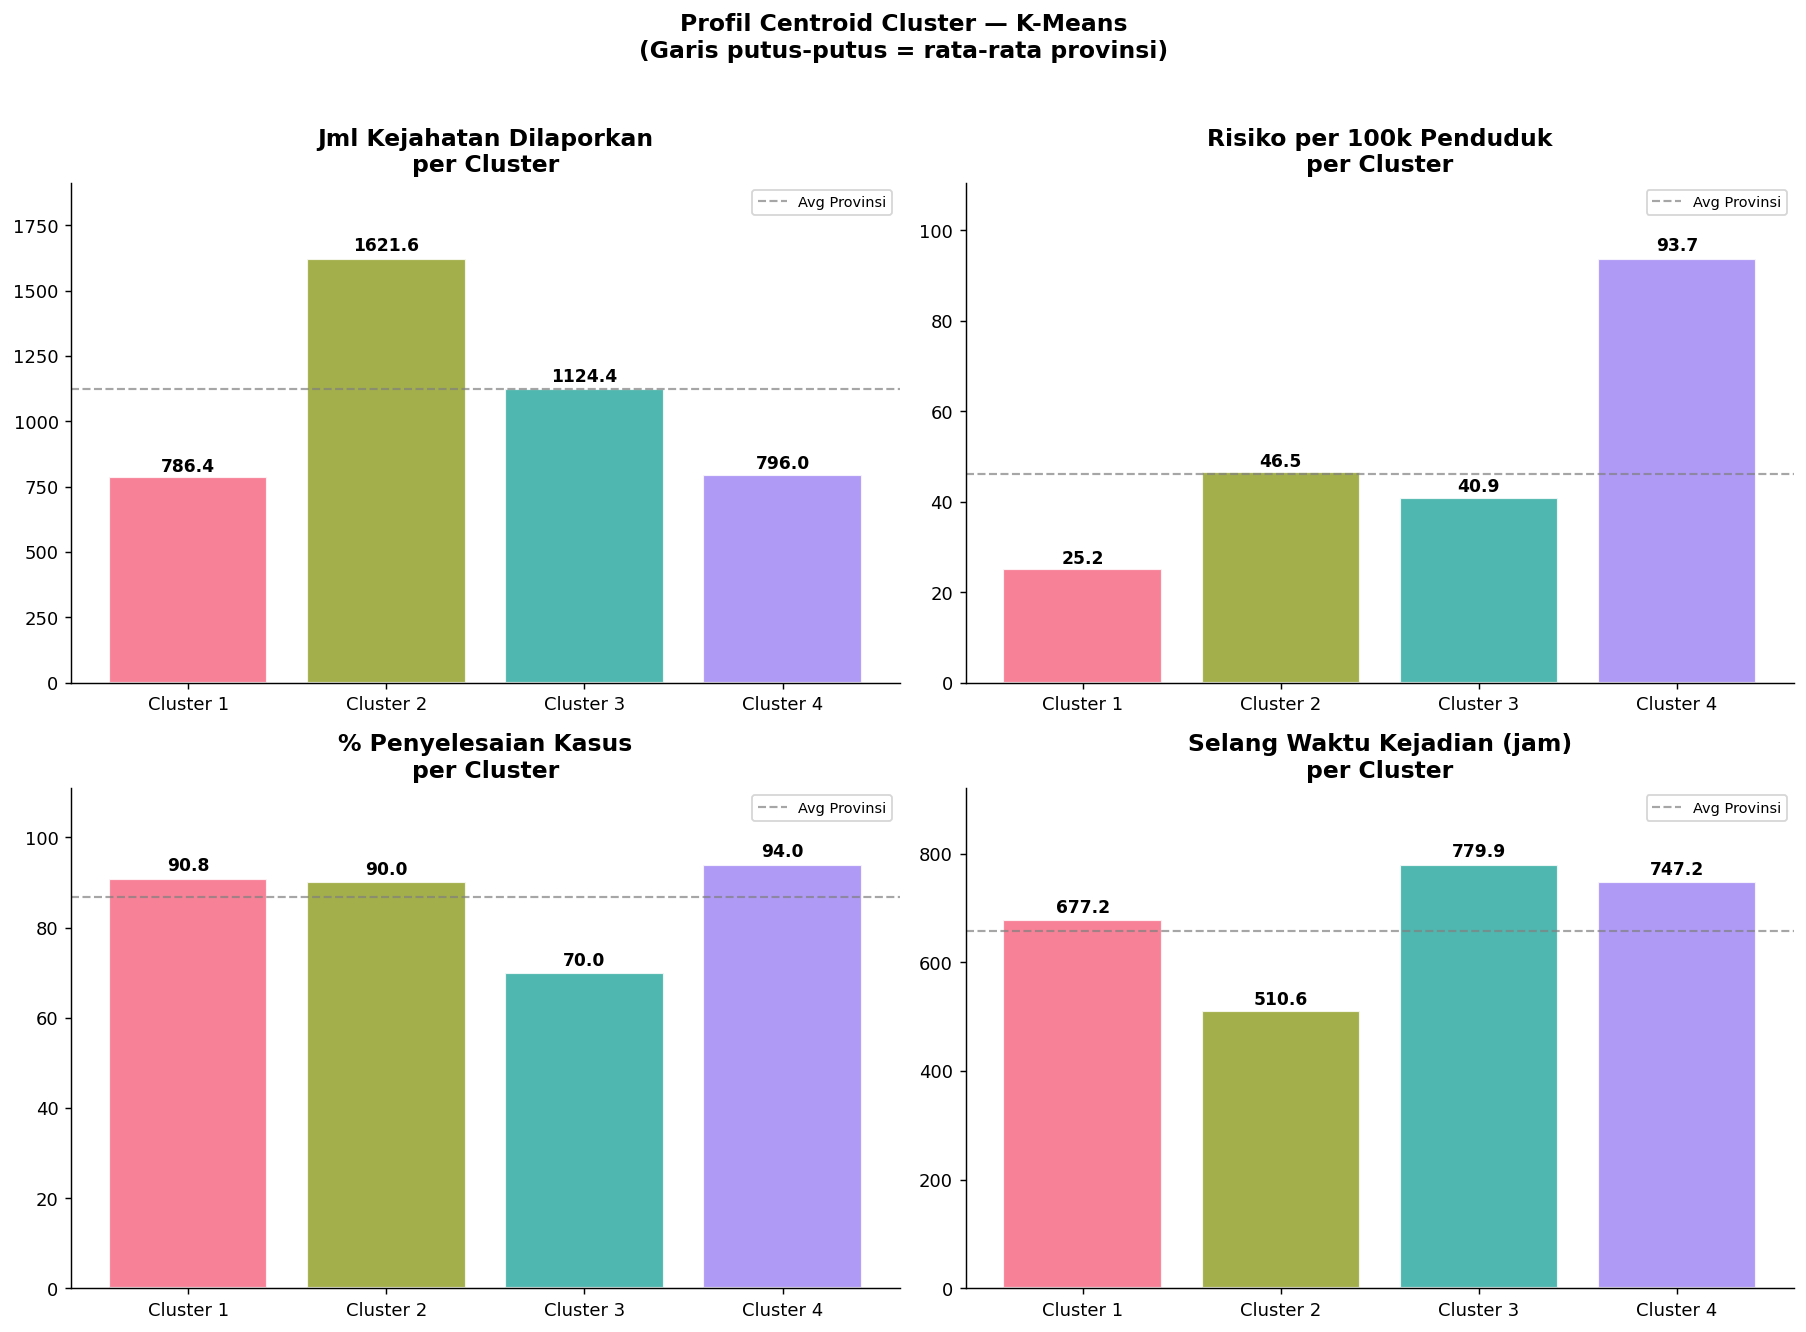

In [158]:
# ── Visualisasi Bar Chart Profil Cluster ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
col_list_bar = sns.color_palette('husl', OPTIMAL_K)
bar_labels   = list(FEATURE_LABELS.values())

for fi, (col, lbl) in enumerate(zip(FEATURE_COLS, bar_labels)):
    vals  = df_clean.groupby('Cluster_KMeans')[col].mean()
    idx   = [f'Cluster {i+1}' for i in vals.index]
    bars  = axes[fi].bar(idx, vals.values,
                          color=[col_list_bar[j] for j in range(OPTIMAL_K)],
                          edgecolor='white', linewidth=1.2, alpha=0.88)
    # Annotate values
    for bar, val in zip(bars, vals.values):
        axes[fi].text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() * 1.01, f'{val:.1f}',
                      ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    # Grand mean reference line
    axes[fi].axhline(df_clean[col].mean(), color='grey', linestyle='--',
                     linewidth=1.2, alpha=0.7, label='Avg Provinsi')
    axes[fi].set_title(f'{lbl.replace(chr(10), " ")}\nper Cluster', fontweight='bold')
    axes[fi].legend(fontsize=8)
    axes[fi].set_ylim(0, vals.max() * 1.18)

fig.suptitle('Profil Centroid Cluster — K-Means\n'
             '(Garis putus-putus = rata-rata provinsi)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_profiles.png', bbox_inches='tight', dpi=130)
plt.show()

### 8.2 Pelabelan Profil Risiko Intuitif
Setiap cluster diberi label deskriptif berdasarkan **Danger Score komposit** yang
mempertimbangkan seluruh dimensi:

| Dimensi | Arah Berbahaya | Bobot |
|---|---|---|
| Jumlah Kejahatan | Tinggi | 25 % |
| Risiko per 100k  | Tinggi | 25 % |
| % Penyelesaian   | Rendah | 25 % |
| Selang Waktu     | Pendek (rendah) | 25 % |

In [159]:
# ── Hitung Danger Score Komposit ─────────────────────────────────────────────
max_crime  = centroid_tbl['Jml Kejahatan'].max()
max_risk   = centroid_tbl['Risiko/100k'].max()
max_pct    = centroid_tbl['% Penyelesaian'].max()
max_selang = centroid_tbl['Selang Waktu'].max()

centroid_tbl['Danger_Score'] = (
    (centroid_tbl['Jml Kejahatan']   / max_crime)  * 25 +
    (centroid_tbl['Risiko/100k']     / max_risk)   * 25 +
    (1 - centroid_tbl['% Penyelesaian'] / max_pct) * 25 +
    (1 - centroid_tbl['Selang Waktu']  / max_selang) * 25
).round(2)

centroid_tbl_s = centroid_tbl.sort_values('Danger_Score', ascending=False).reset_index(drop=False)

# ── Assign Risk Labels berdasarkan rank Danger Score (dinamis untuk K apapun) ─
def get_risk_label(rank, total):
    pct = rank / max(total - 1, 1)
    if pct < 0.25:
        return '🔴 High Risk – Low Resolution'
    elif pct < 0.50:
        return '🟠 Moderate-High Risk – Needs Attention'
    elif pct < 0.75:
        return '🟡 Moderate-Low Risk – Watch Zone'
    else:
        return '🟢 Safe Zone – Low Priority'

n_clusters_actual = len(centroid_tbl_s)
centroid_tbl_s['Profil Risiko'] = [
    get_risk_label(i, n_clusters_actual) for i in range(n_clusters_actual)
]

print("=" * 85)
print("  TABEL PROFIL RISIKO CLUSTER — FINAL")
print("=" * 85)
display_cols = ['index', 'Jml Kejahatan', 'Risiko/100k',
                '% Penyelesaian', 'Selang Waktu', 'N Daerah',
                'Danger_Score', 'Profil Risiko']
print(centroid_tbl_s[display_cols].rename(columns={'index': 'Cluster'}).to_string(index=False))

  TABEL PROFIL RISIKO CLUSTER — FINAL
  Cluster  Jml Kejahatan  Risiko/100k  % Penyelesaian  Selang Waktu  N Daerah  Danger_Score                          Profil Risiko
Cluster 2        1621.58        46.50           90.03        510.62        12         47.08           🔴 High Risk – Low Resolution
Cluster 4         796.00        93.73           93.97        747.18         6         38.32 🟠 Moderate-High Risk – Needs Attention
Cluster 3        1124.38        40.88           69.97        779.88         8         34.62       🟡 Moderate-Low Risk – Watch Zone
Cluster 1         786.42        25.17           90.85        677.23        12         22.96             🟢 Safe Zone – Low Priority


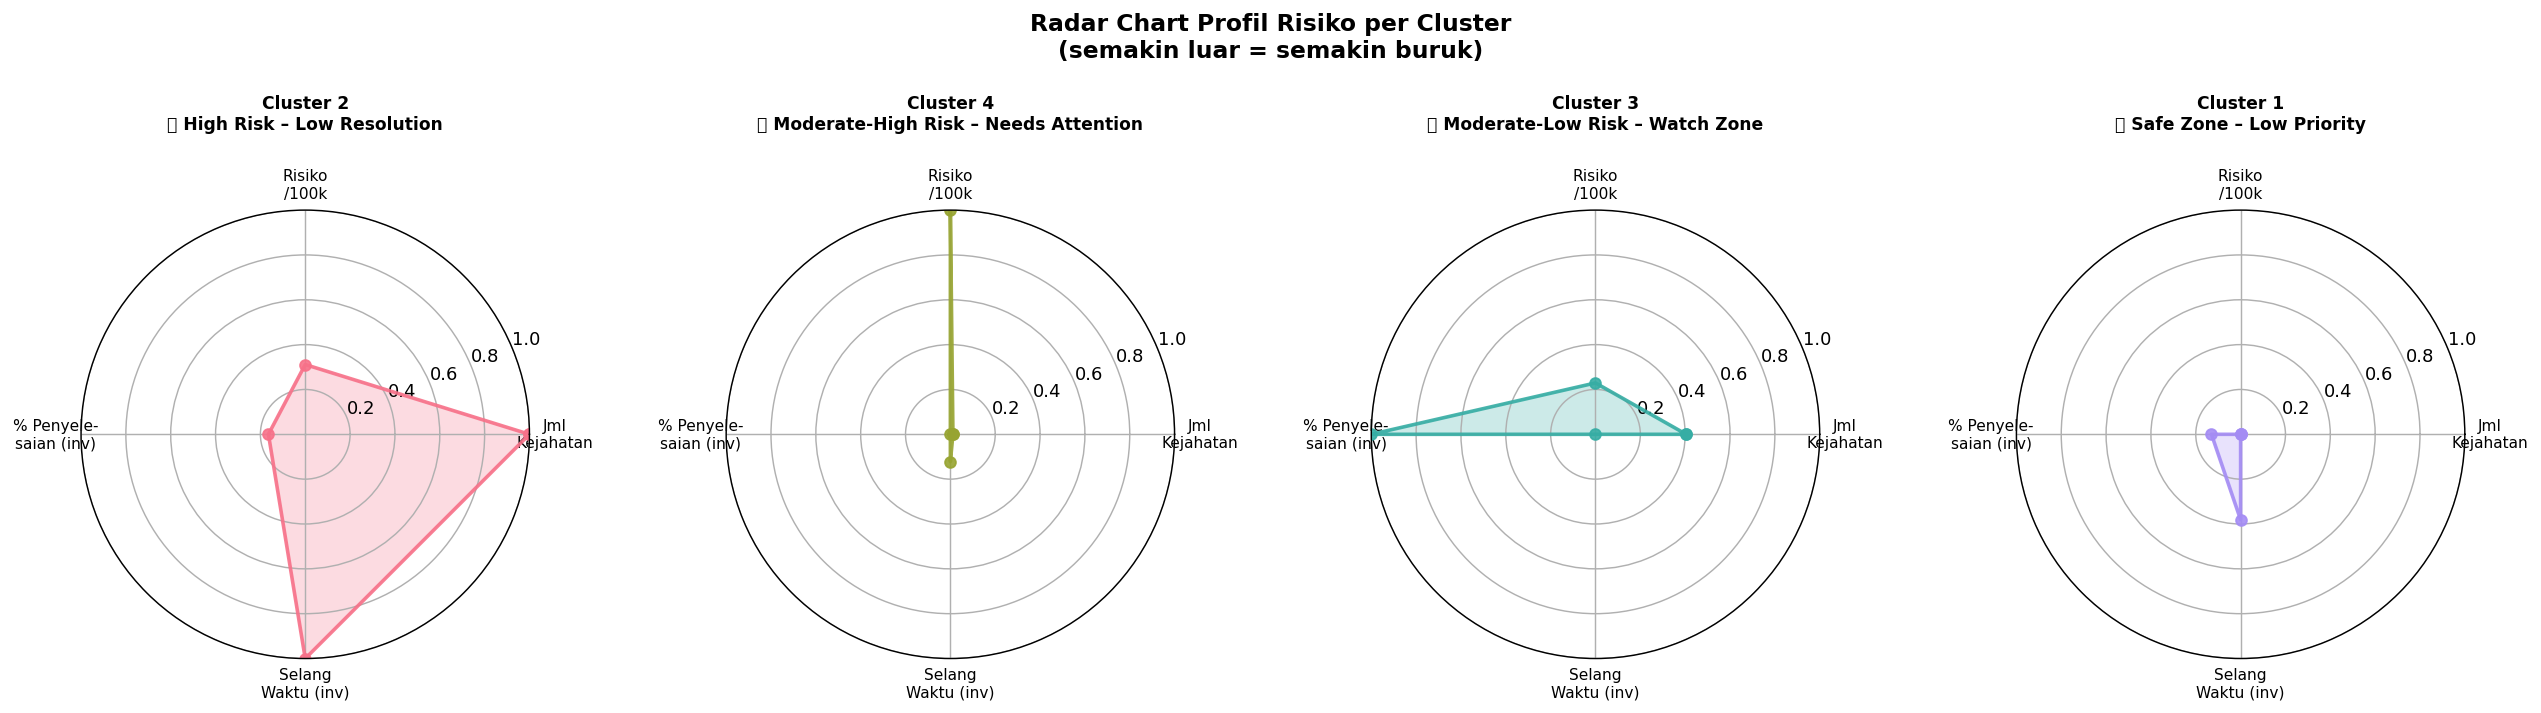

In [160]:
# ── Radar Chart / Spider Plot per Cluster ────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

# Normalisasi 0-1 untuk Radar
radar_data = centroid_tbl_s.set_index('index')[
    ['Jml Kejahatan', 'Risiko/100k', '% Penyelesaian', 'Selang Waktu']
].copy()

# Risiko dan kejahatan: min=baik, max=buruk → normalize as-is
# Penyelesaian dan Selang Waktu: max=baik → invert
radar_norm = radar_data.copy()
for col in radar_norm.columns:
    col_min, col_max = radar_norm[col].min(), radar_norm[col].max()
    radar_norm[col] = (radar_norm[col] - col_min) / (col_max - col_min + 1e-9)

# Invert "baik jika tinggi" metrics agar arah "luar" = lebih buruk
for good_col in ['% Penyelesaian', 'Selang Waktu']:
    radar_norm[good_col] = 1 - radar_norm[good_col]

categories  = ['Jml\nKejahatan', 'Risiko\n/100k', '% Penyele-\nsaian (inv)',
               'Selang\nWaktu (inv)']
N           = len(categories)
angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles     += angles[:1]

fig, axes_r = plt.subplots(1, n_clusters_actual,
                            figsize=(5 * n_clusters_actual, 5),
                            subplot_kw=dict(polar=True))
if n_clusters_actual == 1:
    axes_r = [axes_r]

for i, (cl_name, ax_r) in enumerate(zip(radar_norm.index, axes_r)):
    vals = radar_norm.loc[cl_name].tolist()
    vals += vals[:1]
    ax_r.plot(angles, vals, 'o-', linewidth=2, color=col_list[i], alpha=0.9)
    ax_r.fill(angles, vals, alpha=0.25, color=col_list[i])
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(categories, fontsize=8.5)
    ax_r.set_ylim(0, 1)
    risk_lbl = centroid_tbl_s.loc[
        centroid_tbl_s['index'] == cl_name, 'Profil Risiko'
    ].values[0]
    ax_r.set_title(f'{cl_name}\n{risk_lbl}', fontsize=9.5,
                   fontweight='bold', pad=15, y=1.12)

fig.suptitle('Radar Chart Profil Risiko per Cluster\n'
             '(semakin luar = semakin buruk)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight', dpi=130)
plt.show()

In [161]:
# ── Peta Daerah per Cluster + Risk Label ─────────────────────────────────────
# Gabungkan cluster label kembali ke df_clean untuk referensi
cluster_label_map = centroid_tbl_s.set_index('index')['Profil Risiko'].to_dict()
df_clean['Risk_Label'] = df_clean['Cluster_KMeans'].map(
    lambda x: cluster_label_map.get(f'Cluster {x+1}', 'Unknown')
)

# Print daftar daerah per profil risiko
print("\n📋  DAFTAR DAERAH BERDASARKAN PROFIL RISIKO")
print("=" * 70)
for cl_name, risk in cluster_label_map.items():
    cl_id  = int(cl_name.replace('Cluster ', '')) - 1
    members = df_clean.loc[df_clean['Cluster_KMeans'] == cl_id, 'Kabupaten_Kota'].tolist()
    print(f"\n  {risk}")
    print(f"  ({len(members)} Daerah): {', '.join(sorted(members))}")


📋  DAFTAR DAERAH BERDASARKAN PROFIL RISIKO

  🔴 High Risk – Low Resolution
  (12 Daerah): Banyuwangi, Bojonegoro, Gresik, Jember, Jombang, Kediri, Kota Surabaya, Lamongan, Malang, Pasuruan, Sidoarjo, Tulungagung

  🟠 Moderate-High Risk – Needs Attention
  (6 Daerah): Kota Kediri, Kota Mojokerto, Kota Pasuruan, Kota Probolinggo, Magetan, Ngawi

  🟡 Moderate-Low Risk – Watch Zone
  (8 Daerah): Bondowoso, Kota Malang, Lumajang, Mojokerto, Pamekasan, Situbondo, Sumenep, Tuban

  🟢 Safe Zone – Low Priority
  (12 Daerah): Bangkalan, Blitar, Kota Batu, Kota Blitar, Kota Madiun, Madiun, Nganjuk, Pacitan, Ponorogo, Probolinggo, Sampang, Trenggalek


In [162]:
# ── Plotly: Interactive Profil Cluster ───────────────────────────────────────
fig_radar = go.Figure()

for i, cl_name in enumerate(radar_norm.index):
    vals    = radar_norm.loc[cl_name].tolist()
    risk_lbl = centroid_tbl_s.loc[
        centroid_tbl_s['index'] == cl_name, 'Profil Risiko'
    ].values[0]
    fig_radar.add_trace(go.Scatterpolar(
        r      = vals + [vals[0]],
        theta  = ['Jml Kejahatan', 'Risiko/100k',
                  '% Penyelesaian (inv)', 'Selang Waktu (inv)',
                  'Jml Kejahatan'],
        fill   = 'toself',
        opacity = 0.65,
        name   = f'{cl_name} — {risk_lbl}',
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=dict(
        text='<b>Radar Chart Profil Risiko Cluster (Interactive)</b><br>'
             '<sup>Nilai ternormalisasi; arah luar = kondisi lebih buruk</sup>',
        font=dict(size=14)
    ),
    template='plotly_white',
    width=750, height=550,
)
fig_radar.show()

## 9. Rekomendasi Strategis Pemerintah Daerah <a id='9-rekomendasi'></a>

---

### 🔴 Cluster "High Risk – Low Resolution"
**Karakteristik:** Jumlah kejahatan tinggi, risiko per kapita besar, tingkat penyelesaian kasus rendah, dan frekuensi kejadian tinggi.

**Rekomendasi:**
- **Penambahan personil Polri** secara segera — prioritas utama redistribusi aset keamanan provinsi
- **Program percepatan penyelesaian kasus** (`case clearance rate`): pelatihan penyidik, pemanfaatan teknologi forensik digital
- **Pos Keamanan Terpadu (Poskamtibmas)** di titik-titik kriminalitas tinggi berbasis pemetaan GIS
- **Perkuat unit intelijen kriminal** untuk investigasi proaktif, bukan reaktif

---

### 🟠 Cluster "Moderate-High Risk – Needs Attention"
**Karakteristik:** Frekuensi kejahatan dan risiko di atas rata-rata, penyelesaian kasus masih dapat diperbaiki.

**Rekomendasi:**
- **Patroli preventif intensif** pada jam dan lokasi rawan (analisis *hotspot*)
- **Peningkatan koordinasi** antara Polri–Satpol PP–Pemerintah Daerah untuk respons lintas-sektoral
- **Investasi CCTV & sistem pelaporan digital** untuk mempercepat waktu respons
- **Program pemberdayaan ekonomi komunitas** untuk menyasar akar kejahatan berbasis kemiskinan
- Monitoring ketat agar tidak bergeser ke kategori *High Risk*

---

### 🟡 Cluster "Moderate-Low Risk – Watch Zone"
**Karakteristik:** Profil keamanan relatif stabil, namun perlu dijaga agar tidak meningkat.

**Rekomendasi:**
- **Pertahankan kapasitas penegakan hukum** yang sudah berjalan efektif
- **Program komunitas (Siskamling 4.0):** digitalisasi sistem keamanan berbasis RT/RW
- **Evaluasi periodik** terhadap tren kriminalitas — deteksi dini pola anomali musiman
- Alokasi anggaran keamanan **proporsional** — tidak perlu ekspansi besar, fokus pada pemeliharaan

---

### 🟢 Cluster "Safe Zone – Low Priority"
**Karakteristik:** Kriminalitas rendah, risiko per kapita kecil, tingkat penyelesaian baik, frekuensi kejadian panjang.

**Rekomendasi:**
- **Jadikan sebagai model percontohan** bagi daerah dengan profil lebih tinggi
- **Redistribusi sumber daya** (personil, anggaran) dari zona ini ke zona *High Risk*
- **Perkuat sistem pencegahan berbasis masyarakat** untuk mempertahankan kondisi aman
- **Investasi pada kualitas SDM aparat** (pendidikan lanjutan, pelatihan spesialisasi)

---

### 📌 Rekomendasi Lintas-Cluster (Provinsi)

| Prioritas | Aksi | Target Cluster |
|:---:|---|---|
| 🥇 | Redistribusi personil Polri dari Safe Zone ke High Risk | Semua |
| 🥈 | Platform data kriminalitas terintegrasi (Big Data Polda Jatim) | Semua |
| 🥉 | Sistem early-warning berbasis ML untuk prediksi lonjakan kriminalitas | High & Moderate |
| 4 | Anggaran keamanan berbasis *risk score* bukan rata rata merata | Semua |
| 5 | Review tahunan segmentasi cluster menggunakan data terbaru | Semua |

---
> **Catatan Metodologi:** Analisis ini didasarkan pada median multi-tahun (2020–2024) untuk meminimalkan bias anomali tahun tertentu. Segmentasi bersifat dinamis dan perlu diperbarui setiap tahun dengan data terkini. Keputusan kebijakan harus dikombinasikan dengan konteks lapangan dan keahlian domain dari aparat keamanan setempat.

> **Catatan Tambahan Pemilihan K:** Bila konfigurasi granular (misalnya K=9) menghasilkan cluster dengan anggota <4, cluster tersebut diperlakukan sebagai **kasus khusus** yang wajib verifikasi lapangan dan **tidak** dijadikan basis kebijakan langsung.

In [163]:
from IPython.display import display, Markdown

# Aman dari Error: Mencoba mengambil referensi metrik jika ada di globals
try:
    kmeans_silh = f"{silh_km:.4f}"
except:
    kmeans_silh = "[jalankan Cell 28]"

try:
    hc_silh = f"{silh_hc:.4f}" \
        if 'silh_hc' in globals() \
        else "[jalankan Cell 34]"
except:
    hc_silh = "[jalankan Cell 34]"

try:
    ari_val = f"{ari:.4f}" \
        if 'ari' in globals() \
        else "[jalankan Cell 34]"
except:
    ari_val = "[jalankan Cell 34]"

try:
    pca_var = f"{(sum(pca.explained_variance_ratio_[:2]) * 100):.1f}%"
except:
    pca_var = "[Tersedia di Seksi PCA]"

summary_md = f"""---
## 📊 Ringkasan Statistik Analisis (Otomatis)

| Metrik | Nilai Aktual |
|---|---|
| Jumlah Kabupaten/Kota | **{df_clean.shape[0]}** |
| Periode Data | **2020 – 2024 (Agregasi)** |
| Jumlah Fitur | **{len(FEATURE_COLS)}** |
| Jumlah Cluster Optimal | **`K = {OPTIMAL_K}`** |
| K-Means Silhouette Score | `{kmeans_silh}` |
| HC Ward Silhouette Score | `{hc_silh}` |
| Adjusted Rand Index (Stabilitas) | `{ari_val}` |
| PCA Variance Explained (2D) | `{pca_var}` |

*Catatan: Tabel ini sekarang dirender secara programatik langsung dari variabel memori aktif. Jika K berubah, tabel ini akan beradaptasi secara dinamis.*
"""
display(Markdown(summary_md))


---
## 📊 Ringkasan Statistik Analisis (Otomatis)

| Metrik | Nilai Aktual |
|---|---|
| Jumlah Kabupaten/Kota | **38** |
| Periode Data | **2020 – 2024 (Agregasi)** |
| Jumlah Fitur | **4** |
| Jumlah Cluster Optimal | **`K = 4`** |
| K-Means Silhouette Score | `0.2829` |
| HC Ward Silhouette Score | `0.2415` |
| Adjusted Rand Index (Stabilitas) | `0.3717` |
| PCA Variance Explained (2D) | `58.1%` |

*Catatan: Tabel ini sekarang dirender secara programatik langsung dari variabel memori aktif. Jika K berubah, tabel ini akan beradaptasi secara dinamis.*


## 10. Analisis Lapisan Tambahan: Tren Temporal Tersembunyi (2020-2024)

Analisis profil *clustering* berbasis *median* (nilai tengah) yang kita selesaikan di atas sangat kuat untuk memetakan "Status Quo" struktural. Namun, pendekatan statistik statis ini rentan menyembunyikan dinamika temporal atau **pola kemerosotan**. 

Sebagai **lapisan analisis preventif tambahan**, kita mengekstraksi parameter **Slope (Kemiringan Regresi Linear) dari *Risiko_100k*** untuk setiap daerah selama periode 2020–2024.
*   **Slope Positif (+):** Kondisi memburuk (tingkat kejahatan/risiko per kapita secara tahunan terus meningkat).
*   **Slope Negatif (-):** Kondisi membaik (terdapat penurunan risiko tahunan yang terstruktur).

**Prioritas Kebijakan Preventif (Titik Buta / Blind Spot):**
Daerah yang terklasifikasi sebagai **"Safe Zone"** (Klaster Risiko Rendah) namun ternyata memiliki **Slope sangat positif** adalah subjek paling mendesak/rentan *(Hidden Emerging Risk)*. Intervensi penangkalan dini pada daerah ini jauh lebih berharga sebelum situasinya membengkak dan mereka bergeser klaster ke "High Risk". <a id='10-tren'></a>

In [164]:
from scipy.stats import linregress
import pandas as pd
import numpy as np

# 1. Menghitung Slope Regresi Linear (Risiko_100k) per wilayah menggunakan data longitudinal (df_raw)
def calc_slope(df_group):
    # Urutkan berdasarkan tahun
    df_sorted = df_group.sort_values("Tahun")
    y = df_sorted["Risiko_100k"].values
    x = np.arange(len(y))
    # Jika datanya lebih dari 1 tahun, hitung regresi
    if len(y) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        return slope
    return 0.0

slope_df = df_raw.groupby("Kabupaten_Kota").apply(calc_slope).reset_index()
slope_df.columns = ["Kabupaten_Kota", "Slope_Risiko"]

# 2. Gabungkan Slope dengan Hasil Klaster Median (df_clean yang sudah dilabeli profil risiko)
df_trend = df_clean[["Kabupaten_Kota", "Cluster_KMeans", "Risk_Label", "Risiko_100k"]].merge(
    slope_df, on="Kabupaten_Kota", how="left"
)

# 3. Ekstraksi Blind Spot: "Safe Zone" / "Moderate-Low Risk" tapi tren pemburukannya ekstrem (Slope positif)
# Kita ambil yang profilnya aman, namun trend (slope) berada di atas persentil 75
threshold_bahaya = max(slope_df["Slope_Risiko"].quantile(0.75), 0.1)

blind_spots = df_trend[
    (df_trend["Risk_Label"].str.contains("Safe|Low")) & 
    (df_trend["Slope_Risiko"] > threshold_bahaya)
].sort_values("Slope_Risiko", ascending=False)

print("┌─────────────────────────────────────────────────────────────┐")
print("│ 🔍 TEMUAN LAPISAN TEMPORAL (HIDDEN EMERGING RISK)             │")
print("└─────────────────────────────────────────────────────────────┘")
if len(blind_spots) > 0:
    print(f"Mengisolasi {len(blind_spots)} Daerah 'Berstatus Aman' dengan tingkat degradasi keamanan paling tinggi:\n")
    display(blind_spots.round(2))
    print("\nRekomendasi Eksekutif:")
    print("Daerah-daerah di tabel atas memerlukan PRIORITAS INTERVENSI KEBIJAKAN PREVENTIF SEGERA.")
    print("Meski median risiko mereka aman, tingkat peningkatannya (Slope) sangat mencemaskan.")
else:
    print("Tidak ditemukan daerah Safe Zone dengan kemerosotan ekstrem.")
    
print("\n\n[ℹ] Data 'Slope_Risiko' ini siap untuk secara otomatis disisipkan ke dalam layer peta_kriminalitas_jatim.html")


┌─────────────────────────────────────────────────────────────┐
│ 🔍 TEMUAN LAPISAN TEMPORAL (HIDDEN EMERGING RISK)             │
└─────────────────────────────────────────────────────────────┘
Mengisolasi 9 Daerah 'Berstatus Aman' dengan tingkat degradasi keamanan paling tinggi:



,Kabupaten_Kota,Cluster_KMeans,Risk_Label,Risiko_100k,Slope_Risiko
9,Kota Batu,0,🟢 Safe Zone – Low Priority,6.0,189.0
13,Kota Malang,2,🟡 Moderate-Low Risk – Watch Zone,58.0,131.1
20,Madiun,0,🟢 Safe Zone – Low Priority,14.0,53.6
23,Mojokerto,2,🟡 Moderate-Low Risk – Watch Zone,42.0,53.4
10,Kota Blitar,0,🟢 Safe Zone – Low Priority,27.0,48.4
12,Kota Madiun,0,🟢 Safe Zone – Low Priority,33.0,40.3
30,Probolinggo,0,🟢 Safe Zone – Low Priority,21.0,38.4
26,Pacitan,0,🟢 Safe Zone – Low Priority,8.0,36.1
27,Pamekasan,2,🟡 Moderate-Low Risk – Watch Zone,44.0,33.8



Rekomendasi Eksekutif:
Daerah-daerah di tabel atas memerlukan PRIORITAS INTERVENSI KEBIJAKAN PREVENTIF SEGERA.
Meski median risiko mereka aman, tingkat peningkatannya (Slope) sangat mencemaskan.


[ℹ] Data 'Slope_Risiko' ini siap untuk secara otomatis disisipkan ke dalam layer peta_kriminalitas_jatim.html


## 12. Limitasi & Catatan Metodologi

Setiap pemodelan _Data Science_ mutlak dituntut untuk mengafirmasi batasan-batasan teknis dari data turunan yang digunakannya. Penjelasan porsi limitasi ini **bukan ditujukan sebagai kelemahan metodologi**, namun mengartikan kematangan intelektual analitis (*Intellectual Humility*) agar pengambil kebijakan di Jawa Timur memahami batas aman interpretasi.

Berikut adalah struktur diskursus mengenai limitasi dari pemodelan K-Means & Agregasi Regional ini:

1. **Efisiensi Bias Winsorization (*Genuine Outlier Dilution*):**
   Model secara paksa menggunakan *Winsorization 95%* pada fitur metrik absolut. Hal ini memang berhasil mencapai objektivitas *Silhouette Score* dengan menjinakkan tarikan *centroid* dari kutub *outlier* ekstrem (misal ekstremitas intensitas perusakan di Kota Surabaya / Medan padat per kapita). Limitasi yang ditimbulkan: Beberapa sentra metropolitan yang sedari awal *super-crime volume* akan memiliki "Profil Statis Terpotong", menjadikannya tampak sedikit lebih moderat (*Under-penalized*) daripada realitas kriminal lapangan yang sesungguhnya gawat.

2. **Kompression Heterogenitas (*Dark Figure of Crime* Region):**
   Penggunaan komposit `Risiko_100k pend.` rentan pada asumsi homogenitas pelaporan hukum. Di beberapa koridor pedesaan *Safe Zone*, metrik ini sangat mungkin lebih mencerminkan "_Low Filing / Low Documentation Rates_" daripada perdamaian sosial literal akibat preferensi masyarakat menggunakan resolusi kekeluargaan konvensional. Angka dokumentasi yang kosong diasumsikan sebagai nihil bahaya, melahirkan potensi Bias Administratif (*Unreported Crime Gap*).

3. **Efek Penghalusan Lintas Waktu (2020-2024 Aggregate Smoothing):**
   *Clustering* sentral ini menempatkan kabupaten/kota sebagai "Entitas Tetap" berdasar rentang 5-Tahun sekaligus. Meski lapisan *Temporal Slope* telah disertakan pasca-clustering, K-Means secara murni buta terhadap lintasan kronologinya (mis: lompatan tinggi seketika di tahun 2021). Evaluasi tahun demi tahun secara singular (pendekatan *Time-Series Clustering*) berpotensi mendudukkan kabupaten ke lintasan klaster yang jauh berbeda pada segmen _outbreak_ spesifik.
 <a id='12-limitasi'></a>

## 11. Visualisasi Spasial Peta Interaktif 🗺️
        
Sesuai dengan arahan pembentukan laporan yang *self-contained* (mandiri), berikut adalah peta interaktif tingkat kerawanan Kabupaten/Kota yang digenerasikan menggunakan Leaflet.js dari file eksternal (`buat_peta.py`), yang kini disematkan (*embedded*) secara utuh ke dalam *notebook* ini.

Anda dapat:
1. Melakukan *Zoom* dan menggeser peta *(Pan)*.
2. Membaca **Saran Strategis** per cluster di panel sebelah kiri.
3. Melakukan klik pada masing-masing wilayah untuk membuka *tooltip* **Danger Score** hingga melihat apakah wilayah tersebut terkena peringatan **🔥 Tren Memburuk**.
 <a id='11-peta'></a>

In [165]:
from IPython.display import IFrame, display
import os

map_file = 'peta_kriminalitas_jatim.html'

if os.path.exists(map_file):
    print("🌍 Merender Peta Interaktif K-Means Jawa Timur...")
    display(IFrame(src='./' + map_file, width='100%', height='800px'))
else:
    print(f"⚠️ File {map_file} tidak ditemukan di direktori saat ini. Pastikan buat_peta.py telah dijalankan.")


🌍 Merender Peta Interaktif K-Means Jawa Timur...
